In [2]:
!pip install geopandas matplotlib
!pip install geodatasets
!pip install rioxarray
!pip install openpyxl
!pip install selenium webdriver-manager
!pip install fiona

!pip install netCDF4
!pip install seaborn
!pip install scipy
!pip install pygam
!pip install mplcursors


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


...


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


citations:
Data Source:

European Space Agency (ESA), 2026. Sentinel-3 OLCI Level-2 Marine Data, available via Copernicus Data Space Ecosystem. Available at: https://dataspace.copernicus.eu [Accessed 28 August 2026].

API / Software Infrastructure:

Copernicus Data Space Ecosystem (CDSE), 2026. OData Catalogue and Zipper API Documentation, European Union / European Space Agency. Available at: https://catalogue.dataspace.copernicus.eu [Accessed 28 August 2026].

In [9]:
import os
import requests
import glob
import zipfile
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

# 1. Download Sentinel 3A and 3B data from Copernicus Data Space Ecosystem utilizing API and OData as listed on their webpage
https://documentation.dataspace.copernicus.eu/APIs/OData.html

In [15]:
### 1st attempt: it was getting stuck and not running all the way through

# ---------------------------------------------------------------------------
# Configuration & Credentials
# ---------------------------------------------------------------------------
USERNAME = "h.doran1@universityofgalway.ie"
PASSWORD = "ihateAngela69**##"

# Spatial & Temporal Filters (e.g., Irish Sea / Coastal Waters)
START_DATE = "2026-04-26T00:00:00.000Z"
END_DATE = "2026-05-11T23:59:59.999Z"

# Bounding Box [min_lon, min_lat, max_lon, max_lat]
BBOX = [-9.9, 53.1, -8.8, 53.4]

# Product Type for Water-Leaving Reflectance / Ocean Colour
# Use 'OL_2_WFR___' for 300m Full Resolution or 'OL_2_WRR___' for 1.2km Reduced Resolution
PRODUCT_TYPE = "OL_2_WFR___"


def get_access_token(username, password):
    """Retrieves OAuth2 access token for Copernicus Data Space Ecosystem."""
    token_url = "https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token"
    payload = {
        "client_id": "cdse-public",
        "username": username,
        "password": password,
        "grant_type": "password",
    }
    response = requests.post(token_url, data=payload)
    response.raise_for_status()
    return response.json()["access_token"]


def search_olci_wfr(start_date, end_date, bbox, product_type="OL_2_WFR___", top=100, orderby='asc'):
    """Queries CDSE OData API for OLCI L2 Water products."""
    min_lon, min_lat, max_lon, max_lat = bbox

    # Construct WKT Polygon
    polygon_wkt = f"POLYGON(({min_lon} {min_lat}, {max_lon} {min_lat}, {max_lon} {max_lat}, {min_lon} {max_lat}, {min_lon} {min_lat}))"

    # Build OData filter query string
    filters = [
        "Collection/Name eq 'SENTINEL-3'",
        f"ContentDate/Start gt {start_date}",
        f"ContentDate/Start lt {end_date}",
        f"OData.CSC.Intersects(area=geography'SRID=4326;{polygon_wkt}')",
        f"Attributes/OData.CSC.StringAttribute/any(att:att/Name eq 'productType' and att/OData.CSC.StringAttribute/Value eq '{product_type}')",
    ]

    filter_query = " and ".join(filters)
    endpoint = f"https://catalogue.dataspace.copernicus.eu/odata/v1/Products?$filter={filter_query}&$top={top}&$orderby=ContentDate/Start desc"

    response = requests.get(endpoint)
    response.raise_for_status()
    return response.json().get("value", [])


def download_product(product_id, product_name, token, output_dir="."):
    """Downloads the full product ZIP container."""
    download_url = f"https://zipper.dataspace.copernicus.eu/odata/v1/Products({product_id})/$value"
    headers = {"Authorization": f"Bearer {token}"}

    output_path = os.path.join(output_dir, f"{product_name}.zip")
    # 1. Skip if file is already completely downloaded
    if os.path.exists(output_path) and os.path.getsize(output_path) > 100_000_000:  # >100MB check
        print(f"⏩ {product_name}.zip already exists. Skipping.")
        return
    print(f"Downloading {product_name}...")

    with requests.get(download_url, headers=headers, stream=True, timeout=(15,60)) as r:
        r.raise_for_status()
        with open(output_path, "wb") as f:
            for chunk in r.iter_content(chunk_size=8192):
                f.write(chunk)

    print(f"Saved to {output_path}")


if __name__ == "__main__":
    print(f"Searching for {PRODUCT_TYPE} datasets...")
    results = search_olci_wfr(
        START_DATE, END_DATE, BBOX, product_type=PRODUCT_TYPE, top=100, orderby='asc'
    )

    print(f"Found {len(results)} matching product(s).")
    for r in results:
        print(f"Name: {r['Name']} | Date: {r['ContentDate']['Start']}")

    if results:
        token = get_access_token(USERNAME, PASSWORD)

        # Set target directory
        output_dir = "Sentinel_Data"
        os.makedirs(output_dir, exist_ok=True)

        print(f"\nStarting batch download of {len(results)} files to ./{output_dir}...")

        # Loop through all results instead of taking only results[0]
        for i, item in enumerate(results, start=1):
            print(f"\n[{i}/{len(results)}]")
            try:
                download_product(item["Id"], item["Name"], token, output_dir=output_dir)
            except Exception as e:
                print(f"Failed to download {item['Name']}: {e}")

Searching for OL_2_WFR___ datasets...
Found 27 matching product(s).
Name: S3B_OL_2_WFR____20260511T110859_20260511T111159_20260512T161713_0179_120_037_1980_MAR_O_NT_004.SEN3 | Date: 2026-05-11T11:08:59.220548Z
Name: S3B_OL_2_WFR____20260510T113510_20260510T113810_20260511T174957_0180_120_023_1980_MAR_O_NT_004.SEN3 | Date: 2026-05-10T11:35:10.208541Z
Name: S3A_OL_2_WFR____20260510T103251_20260510T103551_20260511T165640_0179_139_165_1980_MAR_O_NT_004.SEN3 | Date: 2026-05-10T10:32:50.987068Z
Name: S3A_OL_2_WFR____20260509T105902_20260509T110202_20260510T160048_0179_139_151_1980_MAR_O_NT_004.SEN3 | Date: 2026-05-09T10:59:01.771038Z
Name: S3A_OL_2_WFR____20260508T112513_20260508T112813_20260509T174521_0179_139_137_1980_MAR_O_NT_004.SEN3 | Date: 2026-05-08T11:25:12.569160Z
Name: S3B_OL_2_WFR____20260508T104633_20260508T104933_20260509T164643_0179_119_379_1980_MAR_O_NT_004.SEN3 | Date: 2026-05-08T10:46:32.951728Z
Name: S3B_OL_2_WFR____20260507T111244_20260507T111544_20260508T181833_0179_119_3

KeyboardInterrupt: 

In [18]:
## Attempt 2: Skip the files that are already downloaded, and with this one, I can keyboard interupt the kernel and rerun the cell if it gets slow. It has a timeout limit and will restart an attempt if it gets stuck
import os
import time
import requests

# ---------------------------------------------------------------------------
# Configuration & Credentials
# ---------------------------------------------------------------------------
USERNAME = "h.doran1@universityofgalway.ie"
PASSWORD = "ihateAngela69**##"

# Spatial & Temporal Filters (Galway Bay / Irish Coastal Waters)
START_DATE = "2026-04-26T00:00:00.000Z"
END_DATE = "2026-05-11T23:59:59.999Z"
BBOX = [-9.9, 53.1, -8.8, 53.4]  # [min_lon, min_lat, max_lon, max_lat]

# Product Type for Sentinel-3 Water-Leaving Reflectance / Ocean Colour
PRODUCT_TYPE = "OL_2_WFR___"


def get_access_token(username, password):
    """Retrieves OAuth2 access token for Copernicus Data Space Ecosystem."""
    token_url = "https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token"
    payload = {
        "client_id": "cdse-public",
        "username": username,
        "password": password,
        "grant_type": "password",
    }
    response = requests.post(token_url, data=payload, timeout=15)
    response.raise_for_status()
    return response.json()["access_token"]


def search_olci_wfr(start_date, end_date, bbox, product_type="OL_2_WFR___", top=100):
    """Queries CDSE OData API for OLCI L2 Water products."""
    min_lon, min_lat, max_lon, max_lat = bbox
    polygon_wkt = f"POLYGON(({min_lon} {min_lat}, {max_lon} {min_lat}, {max_lon} {max_lat}, {min_lon} {max_lat}, {min_lon} {min_lat}))"

    filters = [
        "Collection/Name eq 'SENTINEL-3'",
        f"ContentDate/Start gt {start_date}",
        f"ContentDate/Start lt {end_date}",
        f"OData.CSC.Intersects(area=geography'SRID=4326;{polygon_wkt}')",
        f"Attributes/OData.CSC.StringAttribute/any(att:att/Name eq 'productType' and att/OData.CSC.StringAttribute/Value eq '{product_type}')",
    ]

    filter_query = " and ".join(filters)
    endpoint = f"https://catalogue.dataspace.copernicus.eu/odata/v1/Products?$filter={filter_query}&$top={top}&$orderby=ContentDate/Start desc"

    response = requests.get(endpoint, timeout=15)
    response.raise_for_status()
    return response.json().get("value", [])


def download_product_resumable(product_id, product_name, token, output_dir=".", max_retries=3):
    download_url = f"https://zipper.dataspace.copernicus.eu/odata/v1/Products({product_id})/$value"
    output_path = os.path.join(output_dir, f"{product_name}.zip")

    # Local size check (>50MB skip)
    if os.path.exists(output_path):
        current_size = os.path.getsize(output_path)
        if current_size > 50_000_000:
            print(f"⏩ {product_name}.zip is already downloaded ({current_size / (1024*1024):.1f} MB). Skipping.")
            return

    for attempt in range(1, max_retries + 1):
        headers = {"Authorization": f"Bearer {token}"}
        downloaded_bytes = os.path.getsize(output_path) if os.path.exists(output_path) else 0

        if downloaded_bytes > 0:
            headers["Range"] = f"bytes={downloaded_bytes}-"
            print(f"🔄 Resuming {product_name} from {downloaded_bytes / (1024*1024):.1f} MB (Attempt {attempt}/{max_retries})...")
        else:
            print(f"Downloading {product_name} (Attempt {attempt}/{max_retries})...")

        try:
            with requests.get(download_url, headers=headers, stream=True, timeout=(15, 15)) as r:
                if r.status_code not in (200, 206):
                    r.raise_for_status()

                mode = "ab" if downloaded_bytes > 0 and r.status_code == 206 else "wb"
                with open(output_path, mode) as f:
                    last_check_time = time.time()
                    bytes_since_check = 0

                    for chunk in r.iter_content(chunk_size=1024 * 1024):  # 1 MB chunks
                        if chunk:
                            f.write(chunk)
                            downloaded_bytes += len(chunk)
                            bytes_since_check += len(chunk)
                            mb = downloaded_bytes / (1024 * 1024)
                            print(f"\r   Downloaded: {mb:.1f} MB", end="", flush=True)

                            # Speed Check: Every 10 seconds, ensure we got at least 0.5 MB
                            elapsed = time.time() - last_check_time
                            if elapsed >= 10:
                                speed_mb = (bytes_since_check / (1024 * 1024)) / elapsed
                                if speed_mb < 0.05:  # Less than ~50 KB/s
                                    raise TimeoutError(f"Transfer rate fell too low ({speed_mb*1000:.1f} KB/s). Forcing reconnect.")
                                last_check_time = time.time()
                                bytes_since_check = 0

                print()
                print(f"✅ Saved to {output_path}")
                return

        except (requests.exceptions.RequestException, TimeoutError, Exception) as e:
            print(f"\n   ⚠️ {e}")
            if attempt < max_retries:
                print("   Re-establishing a fresh connection to resume...")
                time.sleep(3)
            else:
                print(f"   ❌ Reached max retries for {product_name}. Preserving partial file.")
                raise e


if __name__ == "__main__":
    output_dir = "Sentinel_Data"
    os.makedirs(output_dir, exist_ok=True)

    print(f"Searching for {PRODUCT_TYPE} datasets...")
    results = search_olci_wfr(START_DATE, END_DATE, BBOX, product_type=PRODUCT_TYPE, top=100)
    print(f"Found {len(results)} matching product(s).")

    if results:
        token = get_access_token(USERNAME, PASSWORD)
        failed_products = []

        print(f"\nStarting batch download to ./{output_dir}...\n")

        for i, item in enumerate(results, start=1):
            print(f"[{i}/{len(results)}]")
            try:
                download_product_resumable(item["Id"], item["Name"], token, output_dir=output_dir)
            except Exception:
                print("   Skipping to next scene for now...\n")
                failed_products.append(item["Name"])

        print("\n" + "=" * 50)
        print("Batch download process finished!")
        if failed_products:
            print(f"\n⚠️ {len(failed_products)} file(s) hit max retries, but partial progress was saved:")
            for name in failed_products:
                print(f" - {name}")
            print("\nRe-running this script will pick up right where those partial files left off!")

Searching for OL_2_WFR___ datasets...
Found 27 matching product(s).

Starting batch download to ./Sentinel_Data...

[1/27]
⏩ S3B_OL_2_WFR____20260511T110859_20260511T111159_20260512T161713_0179_120_037_1980_MAR_O_NT_004.SEN3.zip is already downloaded (267.5 MB). Skipping.
[2/27]
⏩ S3B_OL_2_WFR____20260510T113510_20260510T113810_20260511T174957_0180_120_023_1980_MAR_O_NT_004.SEN3.zip is already downloaded (233.9 MB). Skipping.
[3/27]
⏩ S3A_OL_2_WFR____20260510T103251_20260510T103551_20260511T165640_0179_139_165_1980_MAR_O_NT_004.SEN3.zip is already downloaded (357.6 MB). Skipping.
[4/27]
⏩ S3A_OL_2_WFR____20260509T105902_20260509T110202_20260510T160048_0179_139_151_1980_MAR_O_NT_004.SEN3.zip is already downloaded (475.8 MB). Skipping.
[5/27]
⏩ S3A_OL_2_WFR____20260508T112513_20260508T112813_20260509T174521_0179_139_137_1980_MAR_O_NT_004.SEN3.zip is already downloaded (454.5 MB). Skipping.
[6/27]
⏩ S3B_OL_2_WFR____20260508T104633_20260508T104933_20260509T164643_0179_119_379_1980_MAR_O_NT

In [19]:
## Attempt 3: 2 of the files are much smaller than the others, probably because the were interupted mid-download and they weren't picked back up again. So with this cell, it looks for files less than 200MB and redownloads them
import os
import requests

# ---------------------------------------------------------------------------
# Configuration & Credentials
# ---------------------------------------------------------------------------
USERNAME = "h.doran1@universityofgalway.ie"
PASSWORD = "ihateAngela69**##"
OUTPUT_DIR = "Sentinel_Data"
MIN_SIZE_MB = 200  # Any file below 200 MB will be deleted and re-downloaded fresh


def get_access_token(username, password):
    """Retrieves OAuth2 access token for Copernicus Data Space Ecosystem."""
    token_url = "https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token"
    payload = {
        "client_id": "cdse-public",
        "username": username,
        "password": password,
        "grant_type": "password",
    }
    response = requests.post(token_url, data=payload, timeout=15)
    response.raise_for_status()
    return response.json()["access_token"]


def get_product_id_by_name(product_name):
    """Queries CDSE API for the exact product ID matching the scene name."""
    url = f"https://catalogue.dataspace.copernicus.eu/odata/v1/Products?$filter=Name eq '{product_name}'"
    r = requests.get(url, timeout=15)
    r.raise_for_status()
    val = r.json().get("value", [])
    if not val:
        raise ValueError(f"Product '{product_name}' not found on CDSE API.")
    return val[0]["Id"]


def redownload_fresh(product_name, token, output_dir):
    """Completely overwrites and re-downloads a product from 0%."""
    output_path = os.path.join(output_dir, f"{product_name}.zip")
    product_id = get_product_id_by_name(product_name)
    download_url = f"https://zipper.dataspace.copernicus.eu/odata/v1/Products({product_id})/$value"

    headers = {"Authorization": f"Bearer {token}"}

    print(f"🔄 Replacing {product_name}.zip (Downloading fresh from 0 MB)...")

    # Mode 'wb' truncates/overwrites any existing file automatically
    with requests.get(download_url, headers=headers, stream=True, timeout=(15, 30)) as r:
        r.raise_for_status()

        with open(output_path, "wb") as f:
            downloaded_bytes = 0
            for chunk in r.iter_content(chunk_size=1024 * 1024):  # 1 MB chunks
                if chunk:
                    f.write(chunk)
                    downloaded_bytes += len(chunk)
                    mb = downloaded_bytes / (1024 * 1024)
                    print(f"\r   Downloaded: {mb:.1f} MB", end="", flush=True)

    final_mb = os.path.getsize(output_path) / (1024 * 1024)
    print(f"\n✅ Successfully replaced: {product_name}.zip ({final_mb:.1f} MB)")


def cleanup_incomplete_downloads(output_dir, threshold_mb=200):
    """Finds and re-downloads all ZIP files in output_dir smaller than threshold_mb."""
    if not os.path.exists(output_dir):
        print(f"Directory '{output_dir}' does not exist.")
        return

    # Scan for files smaller than threshold_mb
    files_to_replace = []
    for fname in sorted(os.listdir(output_dir)):
        if fname.endswith(".zip"):
            fpath = os.path.join(output_dir, fname)
            size_mb = os.path.getsize(fpath) / (1024 * 1024)
            if size_mb < threshold_mb:
                files_to_replace.append((fname[:-4], size_mb))

    if not files_to_replace:
        print(f"🎉 All ZIP files in '{output_dir}' are complete (> {threshold_mb} MB)!")
        return

    print(f"Found {len(files_to_replace)} partial file(s) (< {threshold_mb} MB) to replace:")
    for name, size in files_to_replace:
        print(f" - {name}.zip ({size:.1f} MB)")

    print("\nAuthenticating with CDSE...")
    token = get_access_token(USERNAME, PASSWORD)

    for i, (name, size) in enumerate(files_to_replace, start=1):
        print(f"\n[{i}/{len(files_to_replace)}]")
        try:
            redownload_fresh(name, token, output_dir)
        except Exception as e:
            print(f"\n   ❌ Failed to re-download {name}: {e}")

    print("\n" + "=" * 50)
    print("Cleanup & Replacement finished!")


if __name__ == "__main__":
    cleanup_incomplete_downloads(OUTPUT_DIR, threshold_mb=MIN_SIZE_MB)

Found 2 partial file(s) (< 200 MB) to replace:
 - S3A_OL_2_WFR____20260430T113240_20260430T113540_20260501T180158_0180_139_023_1980_MAR_O_NT_004.SEN3.zip (94.0 MB)
 - S3A_OL_2_WFR____20260506T103635_20260506T103935_20260507T165600_0180_139_108_1980_MAR_O_NT_004.SEN3.zip (175.9 MB)

Authenticating with CDSE...

[1/2]
🔄 Replacing S3A_OL_2_WFR____20260430T113240_20260430T113540_20260501T180158_0180_139_023_1980_MAR_O_NT_004.SEN3.zip (Downloading fresh from 0 MB)...
   Downloaded: 312.8 MB
✅ Successfully replaced: S3A_OL_2_WFR____20260430T113240_20260430T113540_20260501T180158_0180_139_023_1980_MAR_O_NT_004.SEN3.zip (312.8 MB)

[2/2]
🔄 Replacing S3A_OL_2_WFR____20260506T103635_20260506T103935_20260507T165600_0180_139_108_1980_MAR_O_NT_004.SEN3.zip (Downloading fresh from 0 MB)...
   Downloaded: 455.6 MB
✅ Successfully replaced: S3A_OL_2_WFR____20260506T103635_20260506T103935_20260507T165600_0180_139_108_1980_MAR_O_NT_004.SEN3.zip (455.6 MB)

Cleanup & Replacement finished!


In [22]:
## Attempt 4: One of the files was corrupted, so this goes through and redownloads any files that come back as corrupted

USERNAME = "h.doran1@universityofgalway.ie"
PASSWORD = "ihateAngela69**##"
OUTPUT_DIR = "Sentinel_Data"


def get_access_token(username, password):
    token_url = "https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token"
    payload = {
        "client_id": "cdse-public",
        "username": username,
        "password": password,
        "grant_type": "password",
    }
    r = requests.post(token_url, data=payload, timeout=15)
    r.raise_for_status()
    return r.json()["access_token"]


def get_product_id_by_name(product_name):
    url = f"https://catalogue.dataspace.copernicus.eu/odata/v1/Products?$filter=Name eq '{product_name}'"
    r = requests.get(url, timeout=15)
    r.raise_for_status()
    val = r.json().get("value", [])
    if not val:
        raise ValueError(f"Product '{product_name}' not found on CDSE API.")
    return val[0]["Id"]


def redownload_fresh(product_name, token, output_dir):
    output_path = os.path.join(output_dir, f"{product_name}.zip")
    product_id = get_product_id_by_name(product_name)
    download_url = f"https://zipper.dataspace.copernicus.eu/odata/v1/Products({product_id})/$value"

    headers = {"Authorization": f"Bearer {token}"}

    print(f"🔄 Downloading fresh copy for {product_name}.zip...")

    with requests.get(download_url, headers=headers, stream=True, timeout=(15, 30)) as r:
        r.raise_for_status()
        with open(output_path, "wb") as f:
            downloaded_bytes = 0
            for chunk in r.iter_content(chunk_size=1024 * 1024):
                if chunk:
                    f.write(chunk)
                    downloaded_bytes += len(chunk)
                    print(f"\r   Downloaded: {downloaded_bytes / (1024 * 1024):.1f} MB", end="", flush=True)

    final_mb = os.path.getsize(output_path) / (1024 * 1024)
    print(f"\n✅ Successfully replaced: {product_name}.zip ({final_mb:.1f} MB)")


def fix_corrupted_zips(output_dir):
    if not os.path.exists(output_dir):
        print(f"Directory '{output_dir}' does not exist.")
        return

    corrupted_files = []
    zip_files = sorted([f for f in os.listdir(output_dir) if f.endswith(".zip")])

    print(f"Scanning {len(zip_files)} ZIP files for corruption...")
    for fname in zip_files:
        fpath = os.path.join(output_dir, fname)
        try:
            with zipfile.ZipFile(fpath, "r") as z:
                # Tests overall ZIP header and CRC checksums
                bad_file = z.testzip()
                if bad_file is not None:
                    corrupted_files.append(fname[:-4])
        except zipfile.BadZipFile:
            corrupted_files.append(fname[:-4])

    if not corrupted_files:
        print("🎉 All ZIP files passed integrity checks! None are corrupted.")
        return

    print(f"\nFound {len(corrupted_files)} corrupted file(s):")
    for name in corrupted_files:
        print(f" - {name}.zip")

    print("\nAuthenticating with CDSE...")
    token = get_access_token(USERNAME, PASSWORD)

    for i, name in enumerate(corrupted_files, start=1):
        print(f"\n[{i}/{len(corrupted_files)}]")
        try:
            redownload_fresh(name, token, output_dir)
        except Exception as e:
            print(f"\n   ❌ Failed to re-download {name}: {e}")

    print("\n" + "=" * 50)
    print("Corrupted file replacement finished!")


if __name__ == "__main__":
    fix_corrupted_zips(OUTPUT_DIR)

Scanning 27 ZIP files for corruption...

Found 1 corrupted file(s):
 - S3B_OL_2_WFR____20260511T110859_20260511T111159_20260512T161713_0179_120_037_1980_MAR_O_NT_004.SEN3.zip

Authenticating with CDSE...

[1/1]
🔄 Downloading fresh copy for S3B_OL_2_WFR____20260511T110859_20260511T111159_20260512T161713_0179_120_037_1980_MAR_O_NT_004.SEN3.zip...
   Downloaded: 263.5 MB
✅ Successfully replaced: S3B_OL_2_WFR____20260511T110859_20260511T111159_20260512T161713_0179_120_037_1980_MAR_O_NT_004.SEN3.zip (263.5 MB)

Corrupted file replacement finished!


 # 2. Start Loading in Data, and select the files of interest


In [20]:

# zip file name
zip_path = "S3B_OL_2_WFR____20260511T110859_20260511T111159_20260512T161713_0179_120_037_1980_MAR_O_NT_004.SEN3.zip"

with zipfile.ZipFile(zip_path, "r") as z:
    # Get all file paths inside the zip
    all_members = z.namelist()

    # Extract just the file names (stripping folder paths)
    filenames = sorted(
        list(set(os.path.basename(m) for m in all_members if os.path.basename(m)))
    )

print(f"--- TOTAL FILES IN ZIP: {len(filenames)} ---\n")
for f in filenames:
    print(f)

--- TOTAL FILES IN ZIP: 38 ---

EOPMetadata.xml
Oa01_reflectance.nc
Oa02_reflectance.nc
Oa03_reflectance.nc
Oa04_reflectance.nc
Oa05_reflectance.nc
Oa06_reflectance.nc
Oa07_reflectance.nc
Oa08_reflectance.nc
Oa09_reflectance.nc
Oa10_reflectance.nc
Oa11_reflectance.nc
Oa12_reflectance.nc
Oa16_reflectance.nc
Oa17_reflectance.nc
Oa18_reflectance.nc
Oa21_reflectance.nc
S3B_OL_2_WFR____20260511T110859_20260511T111159_20260512T161713_0179_120_037_1980_MAR_O_NT_004-ql.jpg
browse.jpg
chl_nn.nc
chlor_a.nc
fluorescence.nc
geo_coordinates.nc
instrument_data.nc
iop_lsd.nc
iop_nn.nc
iwv.nc
manifest.xml
par.nc
tie_geo_coordinates.nc
tie_geometries.nc
tie_meteo.nc
time_coordinates.nc
trsp.nc
tsm_nn.nc
w_aer.nc
wqsf.nc
xfdumanifest.xml


In [24]:
import os
import re
import zipfile

ZIP_DIR = "Sentinel_Data"
OUTPUT_DIR = "Extracted_OLCI_2"

TARGET_FILES = {
    "geo_coordinates.nc",
    "time_coordinates.nc",
    "tie_geometries.nc",
    "wqsf.nc",
    "instrument_data.nc",
    # Reflectance bands (400 nm to 1020 nm)
    "Oa01_reflectance.nc",
    "Oa02_reflectance.nc",
    "Oa03_reflectance.nc",
    "Oa04_reflectance.nc",
    "Oa05_reflectance.nc",
    "Oa06_reflectance.nc",
    "Oa07_reflectance.nc",
    "Oa08_reflectance.nc",
    "Oa09_reflectance.nc",
    "Oa10_reflectance.nc",
    "Oa11_reflectance.nc",
    "Oa12_reflectance.nc",
    "Oa16_reflectance.nc",
    "Oa17_reflectance.nc",
    "Oa18_reflectance.nc",
    "Oa21_reflectance.nc",
    # Bio-optical products
    "chlor_a.nc",
    "tsm_nn.nc",
}


def parse_scene_metadata(zip_name):
    """Extracts satellite platform (S3A/S3B), date, and time from scene filename."""
    # Extract satellite platform (S3A or S3B)
    platform_match = re.match(r"^(S3[AB])_", zip_name)
    platform = platform_match.group(1) if platform_match else "S3"

    # Extract sensing start date and time
    dt_match = re.search(r"_(\d{8}T\d{6})_", zip_name)
    if dt_match:
        dt_str = dt_match.group(1)
        date_str = f"{dt_str[:4]}-{dt_str[4:6]}-{dt_str[6:8]}"
        time_str = f"{dt_str[9:11]}-{dt_str[11:13]}-{dt_str[13:15]}"
    else:
        date_str, time_str = "Unknown_Date", "Unknown_Time"

    return platform, date_str, time_str


def extract_target_netcdfs(zip_dir, output_dir, target_files):
    if not os.path.exists(zip_dir):
        print(f"Error: Directory '{zip_dir}' not found.")
        return

    os.makedirs(output_dir, exist_ok=True)
    zip_files = [f for f in os.listdir(zip_dir) if f.endswith(".zip")]

    print(f"Found {len(zip_files)} zip file(s) to process.\n")

    for idx, zip_name in enumerate(sorted(zip_files), start=1):
        zip_path = os.path.join(zip_dir, zip_name)

        platform, date_str, time_str = parse_scene_metadata(zip_name)

        # Output folder per acquisition: Extracted_OLCI/2026-04-26/10-15-00/
        scene_output_dir = os.path.join(output_dir, date_str, time_str)
        os.makedirs(scene_output_dir, exist_ok=True)

        print(f"[{idx}/{len(zip_files)}] Extracting [{platform}] scene for {date_str} at {time_str} UTC...")

        extracted_count = 0
        try:
            with zipfile.ZipFile(zip_path, "r") as z:
                for member in z.namelist():
                    filename = os.path.basename(member)

                    if filename in target_files:
                        # Add platform prefix to output filename (e.g., S3A_Oa01_reflectance.nc)
                        prefixed_filename = f"{platform}_{filename}"
                        target_path = os.path.join(scene_output_dir, prefixed_filename)

                        with z.open(member) as source, open(target_path, "wb") as target:
                            target.write(source.read())
                        extracted_count += 1

            print(f"   ✅ Extracted {extracted_count} file(s) as '{platform}_*.nc' to: {scene_output_dir}")

        except zipfile.BadZipFile:
            print(f"   ❌ Skipping corrupted zip archive: {zip_name} (Run fix_corrupted_zips script first)")
        except Exception as e:
            print(f"   ❌ Error extracting {zip_name}: {e}")

    print("\n" + "=" * 50)
    print("Batch extraction complete!")


if __name__ == "__main__":
    extract_target_netcdfs(ZIP_DIR, OUTPUT_DIR, TARGET_FILES)

Found 27 zip file(s) to process.

[1/27] Extracting [S3A] scene for 2026-04-26 at 11-36-24 UTC...
   ✅ Extracted 23 file(s) as 'S3A_*.nc' to: Extracted_OLCI_2\2026-04-26\11-36-24
[2/27] Extracting [S3A] scene for 2026-04-27 at 11-10-13 UTC...
   ✅ Extracted 23 file(s) as 'S3A_*.nc' to: Extracted_OLCI_2\2026-04-27\11-10-13
[3/27] Extracting [S3A] scene for 2026-04-28 at 10-44-02 UTC...
   ✅ Extracted 23 file(s) as 'S3A_*.nc' to: Extracted_OLCI_2\2026-04-28\10-44-02
[4/27] Extracting [S3A] scene for 2026-04-30 at 11-32-40 UTC...
   ✅ Extracted 23 file(s) as 'S3A_*.nc' to: Extracted_OLCI_2\2026-04-30\11-32-40
[5/27] Extracting [S3A] scene for 2026-05-01 at 11-06-29 UTC...
   ✅ Extracted 23 file(s) as 'S3A_*.nc' to: Extracted_OLCI_2\2026-05-01\11-06-29
[6/27] Extracting [S3A] scene for 2026-05-02 at 10-40-19 UTC...
   ✅ Extracted 23 file(s) as 'S3A_*.nc' to: Extracted_OLCI_2\2026-05-02\10-40-19
[7/27] Extracting [S3A] scene for 2026-05-04 at 11-28-56 UTC...
   ✅ Extracted 23 file(s) as 'S3

In [ ]:
## now all the files are extracted, I have the reflectances I want, chlorophyll-a, tsm, the geometries, coordinates and time, and some of the instrument data which may be helpful for

## 3. Make it into a pandas dataframe, with the center wavelength the column name
Need to divide the reflectances (water leaving reflectance) by pi to get it into Rrs

### These ones didnt work

In [26]:
## didn't work - only pulled out two bands, and made it so 3A and 3B are under a "platform" column, which led to almost every other line having NaNs
import os
import glob
import numpy as np
import pandas as pd
import xarray as xr

EXTRACTED_DIR = "Extracted_OLCI_2"
PI = np.pi

# List of target reflectance files in order
BAND_FILES = [
    "Oa01_reflectance.nc", "Oa02_reflectance.nc", "Oa03_reflectance.nc",
    "Oa04_reflectance.nc", "Oa05_reflectance.nc", "Oa06_reflectance.nc",
    "Oa07_reflectance.nc", "Oa08_reflectance.nc", "Oa09_reflectance.nc",
    "Oa10_reflectance.nc", "Oa11_reflectance.nc", "Oa12_reflectance.nc",
    "Oa16_reflectance.nc", "Oa17_reflectance.nc", "Oa18_reflectance.nc",
    "Oa21_reflectance.nc"
]


def get_exact_wavelengths(scene_path, files_in_scene):
    """Extracts exact center wavelengths (lambda0) from instrument_data.nc."""
    inst_file = [f for f in files_in_scene if f.endswith("instrument_data.nc")]
    if not inst_file:
        return None

    inst_path = os.path.join(scene_path, inst_file[0])
    try:
        with xr.open_dataset(inst_path) as ds:
            if "lambda0" in ds:
                # Get mean center wavelength across the detector rows for each band
                lambda0_vals = ds["lambda0"].values
                if lambda0_vals.ndim > 1:
                    lambda0_vals = np.mean(lambda0_vals, axis=0)
                return lambda0_vals
    except Exception as e:
        print(f"Warning: Could not read lambda0 from {inst_file[0]}: {e}")
    return None


def build_rrs_dataframe_exact_bands(extracted_dir):
    records = []
    scene_dirs = sorted(glob.glob(os.path.join(extracted_dir, "*", "*")))

    if not scene_dirs:
        print(f"No scene directories found in '{extracted_dir}'.")
        return pd.DataFrame()

    print(f"Processing {len(scene_dirs)} scene(s)...")

    for scene_path in scene_dirs:
        folder_time = os.path.basename(scene_path)
        folder_date = os.path.basename(os.path.dirname(scene_path))
        dt = pd.to_datetime(f"{folder_date} {folder_time.replace('-', ':')}")

        files_in_scene = os.listdir(scene_path)

        # Determine platform
        platform = "S3A" if any(f.startswith("S3A_") for f in files_in_scene) else (
            "S3B" if any(f.startswith("S3B_") for f in files_in_scene) else "S3")

        row_data = {"datetime": dt, "platform": platform}

        # Try getting exact wavelengths for column headers
        exact_lambdas = get_exact_wavelengths(scene_path, files_in_scene)

        for i, target_nc in enumerate(BAND_FILES):
            matching_files = [f for f in files_in_scene if f.endswith(target_nc)]

            # Label with exact decimal wavelength if available, otherwise nominal fallback
            if exact_lambdas is not None and i < len(exact_lambdas):
                col_name = f"Rrs_{exact_lambdas[i]:.1f}"
            else:
                col_name = f"Rrs_{target_nc.split('_')[0]}"

            if not matching_files:
                row_data[col_name] = np.nan
                continue

            nc_path = os.path.join(scene_path, matching_files[0])

            try:
                with xr.open_dataset(nc_path) as ds:
                    var_name = target_nc.replace(".nc", "")
                    if var_name in ds:
                        data = ds[var_name].values
                        valid_data = data[~np.isnan(data) & (data > 0)]
                        if len(valid_data) > 0:
                            row_data[col_name] = np.median(valid_data) / PI
                        else:
                            row_data[col_name] = np.nan
                    else:
                        row_data[col_name] = np.nan
            except Exception:
                row_data[col_name] = np.nan

        records.append(row_data)

    df = pd.DataFrame(records)
    if not df.empty:
        df.set_index("datetime", inplace=True)
        df.sort_index(inplace=True)

    return df


if __name__ == "__main__":
    rrs_df = build_rrs_dataframe_exact_bands(EXTRACTED_DIR)
    print("\n--- Summary DataFrame with Exact Center Wavelengths ---")
    print(rrs_df.head())
    rrs_df.to_csv("Sentinel3_OLCI_Rrs_ExactBands.csv")

Processing 27 scene(s)...


C:\Users\25298423\PycharmProjects\JupyterProject1\.venv\Lib\site-packages\xarray\namedarray\core.py:261: UserWarning: Duplicate dimension names present: dimensions {'bands'} appear more than once in dims=('bands', 'bands'). We do not yet support duplicate dimension names, but we do allow initial construction of the object. We recommend you rename the dims immediately to become distinct, as most xarray functionality is likely to fail silently if you do not. To rename the dimensions you will need to set the ``.dims`` attribute of each variable, ``e.g. var.dims=('x0', 'x1')``.
  self._dims = self._parse_dimensions(dims)
C:\Users\25298423\PycharmProjects\JupyterProject1\.venv\Lib\site-packages\xarray\namedarray\core.py:261: UserWarning: Duplicate dimension names present: dimensions {'bands'} appear more than once in dims=('bands', 'bands'). We do not yet support duplicate dimension names, but we do allow initial construction of the object. We recommend you rename the dims immediately to be


--- Summary DataFrame with Exact Center Wavelengths ---
                    platform  Rrs_695.3  Rrs_695.5
datetime                                          
2026-04-26 10:57:45      S3B   0.000150        NaN
2026-04-26 11:36:24      S3A        NaN   0.000135
2026-04-27 10:31:35      S3B   0.000133        NaN
2026-04-27 11:10:13      S3A        NaN   0.000157
2026-04-28 10:44:02      S3A        NaN   0.000111


In [27]:
rrs_df

,platform,Rrs_695.3,Rrs_695.5
datetime,,,
2026-04-26 10:57:45,S3B,0.000150,NaN
2026-04-26 11:36:24,S3A,NaN,0.000135
2026-04-27 10:31:35,S3B,0.000133,NaN
2026-04-27 11:10:13,S3A,NaN,0.000157
2026-04-28 10:44:02,S3A,NaN,0.000111
2026-04-28 11:46:23,S3B,0.000150,NaN
2026-04-29 11:20:12,S3B,0.000078,NaN
2026-04-30 10:54:02,S3B,0.000087,NaN
2026-04-30 11:32:40,S3A,NaN,0.000165


In [29]:
## still didn't work, only shows one band, but it does have it in two different dataframes. For next one, need to add latitude and longitude to make sure I can pair it to the sample sites
import os
import glob
import numpy as np
import pandas as pd
import xarray as xr

EXTRACTED_DIR = "Extracted_OLCI_2"
PI = np.pi

# Target L2 ocean color reflectance bands (Oa01 through Oa21)
BAND_FILES = [
    "Oa01_reflectance.nc", "Oa02_reflectance.nc", "Oa03_reflectance.nc",
    "Oa04_reflectance.nc", "Oa05_reflectance.nc", "Oa06_reflectance.nc",
    "Oa07_reflectance.nc", "Oa08_reflectance.nc", "Oa09_reflectance.nc",
    "Oa10_reflectance.nc", "Oa11_reflectance.nc", "Oa12_reflectance.nc",
    "Oa16_reflectance.nc", "Oa17_reflectance.nc", "Oa18_reflectance.nc",
    "Oa21_reflectance.nc"
]

NOMINAL_LAMBDAS = [
    400.0, 412.5, 442.5, 490.0, 510.0, 560.0, 620.0, 665.0,
    673.75, 681.25, 708.75, 753.75, 778.75, 865.0, 885.0, 1020.5
]


def get_band_center_wavelengths(scene_path, files_in_scene):
    """Extract precise detector center wavelengths from instrument_data.nc."""
    inst_file = [f for f in files_in_scene if f.endswith("instrument_data.nc")]
    if not inst_file:
        return NOMINAL_LAMBDAS

    inst_path = os.path.join(scene_path, inst_file[0])
    try:
        with xr.open_dataset(inst_path) as ds:
            if "lambda0" in ds:
                l0 = ds["lambda0"].values
                if l0.ndim == 2:
                    band_center_wl = np.nanmean(l0, axis=0)
                elif l0.ndim == 1:
                    band_center_wl = l0
                else:
                    return NOMINAL_LAMBDAS

                if len(band_center_wl) == 21:
                    band_indices = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 15, 16, 17, 20]
                    band_center_wl = band_center_wl[band_indices]

                return [round(float(w), 1) for w in band_center_wl]
    except Exception:
        pass

    return NOMINAL_LAMBDAS


def build_platform_dataframes(extracted_dir):
    s3a_records = []
    s3b_records = []

    scene_dirs = sorted(glob.glob(os.path.join(extracted_dir, "*", "*")))

    if not scene_dirs:
        print(f"No scene directories found in '{extracted_dir}'.")
        return pd.DataFrame(), pd.DataFrame()

    print(f"Processing {len(scene_dirs)} total scenes into separate S3A/S3B DataFrames...\n")

    for scene_path in scene_dirs:
        folder_time = os.path.basename(scene_path)
        folder_date = os.path.basename(os.path.dirname(scene_path))
        dt = pd.to_datetime(f"{folder_date} {folder_time.replace('-', ':')}")

        files_in_scene = os.listdir(scene_path)

        # Classify sensor platform
        is_s3a = any(f.startswith("S3A_") for f in files_in_scene)
        is_s3b = any(f.startswith("S3B_") for f in files_in_scene)

        # Fallback check on folder path name if prefix is missing
        if not is_s3a and not is_s3b:
            if "S3A" in scene_path:
                is_s3a = True
            elif "S3B" in scene_path:
                is_s3b = True

        row_data = {"datetime": dt}
        center_lambdas = get_band_center_wavelengths(scene_path, files_in_scene)

        # Extract Rrs spectra for all 16 ocean bands
        for i, target_nc in enumerate(BAND_FILES):
            matching_files = [f for f in files_in_scene if f.endswith(target_nc)]
            wl_val = center_lambdas[i] if i < len(center_lambdas) else NOMINAL_LAMBDAS[i]
            col_name = f"Rrs_{wl_val:.1f}"

            if not matching_files:
                row_data[col_name] = np.nan
                continue

            nc_path = os.path.join(scene_path, matching_files[0])

            try:
                with xr.open_dataset(nc_path) as ds:
                    var_name = target_nc.replace(".nc", "")
                    if var_name in ds:
                        data = ds[var_name].values
                        valid_data = data[~np.isnan(data)]
                        row_data[col_name] = (np.median(valid_data) / PI) if len(valid_data) > 0 else np.nan
                    else:
                        row_data[col_name] = np.nan
            except Exception:
                row_data[col_name] = np.nan

        # Append to respective list based on platform
        if is_s3a:
            s3a_records.append(row_data)
        elif is_s3b:
            s3b_records.append(row_data)

    # Build and clean S3A DataFrame
    df_s3a = pd.DataFrame(s3a_records)
    if not df_s3a.empty:
        df_s3a.set_index("datetime", inplace=True)
        df_s3a.sort_index(inplace=True)

    # Build and clean S3B DataFrame
    df_s3b = pd.DataFrame(s3b_records)
    if not df_s3b.empty:
        df_s3b.set_index("datetime", inplace=True)
        df_s3b.sort_index(inplace=True)

    return df_s3a, df_s3b


if __name__ == "__main__":
    df_s3a, df_s3b = build_platform_dataframes(EXTRACTED_DIR)

    print("--- Sentinel-3A DataFrame ---")
    print(df_s3a.head())
    df_s3a.to_csv("Sentinel3A_OLCI_Rrs.csv")
    print(f"Saved S3A ({len(df_s3a)} rows) to 'Sentinel3A_OLCI_Rrs.csv'\n")

    print("--- Sentinel-3B DataFrame ---")
    print(df_s3b.head())
    df_s3b.to_csv("Sentinel3B_OLCI_Rrs.csv")
    print(f"Saved S3B ({len(df_s3b)} rows) to 'Sentinel3B_OLCI_Rrs.csv'")

Processing 27 total scenes into separate S3A/S3B DataFrames...



C:\Users\25298423\PycharmProjects\JupyterProject1\.venv\Lib\site-packages\xarray\namedarray\core.py:261: UserWarning: Duplicate dimension names present: dimensions {'bands'} appear more than once in dims=('bands', 'bands'). We do not yet support duplicate dimension names, but we do allow initial construction of the object. We recommend you rename the dims immediately to become distinct, as most xarray functionality is likely to fail silently if you do not. To rename the dimensions you will need to set the ``.dims`` attribute of each variable, ``e.g. var.dims=('x0', 'x1')``.
  self._dims = self._parse_dimensions(dims)
C:\Users\25298423\PycharmProjects\JupyterProject1\.venv\Lib\site-packages\xarray\namedarray\core.py:261: UserWarning: Duplicate dimension names present: dimensions {'bands'} appear more than once in dims=('bands', 'bands'). We do not yet support duplicate dimension names, but we do allow initial construction of the object. We recommend you rename the dims immediately to be

--- Sentinel-3A DataFrame ---
                     Rrs_695.5
datetime                      
2026-04-26 11:36:24   0.000135
2026-04-27 11:10:13   0.000157
2026-04-28 10:44:02   0.000111
2026-04-30 11:32:40   0.000165
2026-05-01 11:06:29   0.000174
Saved S3A (12 rows) to 'Sentinel3A_OLCI_Rrs.csv'

--- Sentinel-3B DataFrame ---
                     Rrs_695.3
datetime                      
2026-04-26 10:57:45   0.000150
2026-04-27 10:31:35   0.000133
2026-04-28 11:46:23   0.000150
2026-04-29 11:20:12   0.000078
2026-04-30 10:54:02   0.000087
Saved S3B (15 rows) to 'Sentinel3B_OLCI_Rrs.csv'


In [30]:
df_s3b

,Rrs_695.3
datetime,
2026-04-26 10:57:45,0.000150
2026-04-27 10:31:35,0.000133
2026-04-28 11:46:23,0.000150
2026-04-29 11:20:12,0.000078
2026-04-30 10:54:02,0.000087
2026-05-01 10:27:51,0.000050
2026-05-02 11:42:39,0.000100
2026-05-03 11:16:28,0.000161
2026-05-04 10:50:17,0.000161


In [32]:
## didn't work, still only getting one Rrs value, and the latitude and longitude min and max values create way to wide of a value
import os
import glob
import numpy as np
import pandas as pd
import xarray as xr

EXTRACTED_DIR = "Extracted_OLCI_2"
PI = np.pi

# NetCDF band files (Oa01 through Oa21)
BAND_FILES = [
    "Oa01_reflectance.nc", "Oa02_reflectance.nc", "Oa03_reflectance.nc",
    "Oa04_reflectance.nc", "Oa05_reflectance.nc", "Oa06_reflectance.nc",
    "Oa07_reflectance.nc", "Oa08_reflectance.nc", "Oa09_reflectance.nc",
    "Oa10_reflectance.nc", "Oa11_reflectance.nc", "Oa12_reflectance.nc",
    "Oa16_reflectance.nc", "Oa17_reflectance.nc", "Oa18_reflectance.nc",
    "Oa21_reflectance.nc"
]

NOMINAL_LAMBDAS = [
    400.0, 412.5, 442.5, 490.0, 510.0, 560.0, 620.0, 665.0,
    673.75, 681.25, 708.75, 753.75, 778.75, 865.0, 885.0, 1020.5
]


def get_band_center_wavelengths(scene_path, files_in_scene):
    """Extract detector center wavelengths from instrument_data.nc."""
    inst_file = [f for f in files_in_scene if f.endswith("instrument_data.nc")]
    if not inst_file:
        return NOMINAL_LAMBDAS

    inst_path = os.path.join(scene_path, inst_file[0])
    try:
        with xr.open_dataset(inst_path) as ds:
            if "lambda0" in ds:
                l0 = ds["lambda0"].values
                band_center_wl = np.nanmean(l0, axis=0) if l0.ndim == 2 else l0
                if len(band_center_wl) == 21:
                    band_indices = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 15, 16, 17, 20]
                    band_center_wl = band_center_wl[band_indices]
                return [round(float(w), 1) for w in band_center_wl]
    except Exception:
        pass
    return NOMINAL_LAMBDAS


def get_scene_coordinates(scene_path, files_in_scene):
    """
    Extracts latitude and longitude from geo_coordinates.nc.
    Returns center pixel lat/lon as well as spatial bounding limits.
    """
    geo_file = [f for f in files_in_scene if f.endswith("geo_coordinates.nc")]
    if not geo_file:
        return {"latitude": np.nan, "longitude": np.nan,
                "lat_min": np.nan, "lat_max": np.nan,
                "lon_min": np.nan, "lon_max": np.nan}

    geo_path = os.path.join(scene_path, geo_file[0])
    try:
        with xr.open_dataset(geo_path) as ds:
            lats = ds["latitude"].values
            lons = ds["longitude"].values

            # Filter valid coordinate entries
            valid_mask = ~np.isnan(lats) & ~np.isnan(lons)
            if not np.any(valid_mask):
                return {"latitude": np.nan, "longitude": np.nan,
                        "lat_min": np.nan, "lat_max": np.nan,
                        "lon_min": np.nan, "lon_max": np.nan}

            valid_lats = lats[valid_mask]
            valid_lons = lons[valid_mask]

            # Grab exact center pixel if 2D spatial grid
            if lats.ndim == 2:
                cy, cx = lats.shape[0] // 2, lats.shape[1] // 2
                center_lat = float(lats[cy, cx])
                center_lon = float(lons[cy, cx])
            else:
                center_lat = float(np.median(valid_lats))
                center_lon = float(np.median(valid_lons))

            return {
                "latitude": round(center_lat, 5),
                "longitude": round(center_lon, 5),
                "lat_min": round(float(np.min(valid_lats)), 5),
                "lat_max": round(float(np.max(valid_lats)), 5),
                "lon_min": round(float(np.min(valid_lons)), 5),
                "lon_max": round(float(np.max(valid_lons)), 5),
            }
    except Exception as e:
        print(f"Warning: Could not read geo_coordinates.nc in {scene_path}: {e}")
        return {"latitude": np.nan, "longitude": np.nan,
                "lat_min": np.nan, "lat_max": np.nan,
                "lon_min": np.nan, "lon_max": np.nan}


def build_platform_dataframes(extracted_dir):
    s3a_records = []
    s3b_records = []

    scene_dirs = sorted(glob.glob(os.path.join(extracted_dir, "*", "*")))

    if not scene_dirs:
        print(f"No scene directories found in '{extracted_dir}'.")
        return pd.DataFrame(), pd.DataFrame()

    print(f"Processing {len(scene_dirs)} total scenes with geographic coordinates...\n")

    for scene_path in scene_dirs:
        folder_time = os.path.basename(scene_path)
        folder_date = os.path.basename(os.path.dirname(scene_path))
        dt = pd.to_datetime(f"{folder_date} {folder_time.replace('-', ':')}")

        files_in_scene = os.listdir(scene_path)

        # Platform detection
        is_s3a = any(f.startswith("S3A_") for f in files_in_scene) or ("S3A" in scene_path)
        is_s3b = any(f.startswith("S3B_") for f in files_in_scene) or ("S3B" in scene_path)

        row_data = {"datetime": dt}

        # 1. Attach Geographic Coordinates
        coords = get_scene_coordinates(scene_path, files_in_scene)
        row_data.update(coords)

        # 2. Extract Wavelengths and Spectral Data
        center_lambdas = get_band_center_wavelengths(scene_path, files_in_scene)

        for i, target_nc in enumerate(BAND_FILES):
            matching_files = [f for f in files_in_scene if f.endswith(target_nc)]
            wl_val = center_lambdas[i] if i < len(center_lambdas) else NOMINAL_LAMBDAS[i]
            col_name = f"Rrs_{wl_val:.1f}"

            if not matching_files:
                row_data[col_name] = np.nan
                continue

            nc_path = os.path.join(scene_path, matching_files[0])

            try:
                with xr.open_dataset(nc_path) as ds:
                    var_name = target_nc.replace(".nc", "")
                    if var_name in ds:
                        data = ds[var_name].values.astype(float)

                        # Preserve negative values; mask only NaNs and NetCDF _FillValues
                        fill_val = ds[var_name].attrs.get('_FillValue', None)
                        if fill_val is not None:
                            data[data == fill_val] = np.nan

                        valid_data = data[~np.isnan(data)]
                        row_data[col_name] = (np.median(valid_data) / PI) if len(valid_data) > 0 else np.nan
                    else:
                        row_data[col_name] = np.nan
            except Exception:
                row_data[col_name] = np.nan

        # Append to respective satellite list
        if is_s3a:
            s3a_records.append(row_data)
        elif is_s3b:
            s3b_records.append(row_data)

    # Build S3A DataFrame
    df_s3a = pd.DataFrame(s3a_records)
    if not df_s3a.empty:
        df_s3a.set_index("datetime", inplace=True)
        df_s3a.sort_index(inplace=True)

    # Build S3B DataFrame
    df_s3b = pd.DataFrame(s3b_records)
    if not df_s3b.empty:
        df_s3b.set_index("datetime", inplace=True)
        df_s3b.sort_index(inplace=True)

    return df_s3a, df_s3b


if __name__ == "__main__":
    df_s3a, df_s3b = build_platform_dataframes(EXTRACTED_DIR)

    if not df_s3a.empty:
        df_s3a.to_csv("Sentinel3A_OLCI_Rrs.csv")
        print(f"✅ Saved S3A DataFrame ({len(df_s3a)} rows) to 'Sentinel3A_OLCI_Rrs.csv'")
        print(df_s3a[["latitude", "longitude", "lat_min", "lat_max", "Rrs_412.5"]].head())

    if not df_s3b.empty:
        df_s3b.to_csv("Sentinel3B_OLCI_Rrs.csv")
        print(f"\n✅ Saved S3B DataFrame ({len(df_s3b)} rows) to 'Sentinel3B_OLCI_Rrs.csv'")
        print(df_s3b[["latitude", "longitude", "lat_min", "lat_max", "Rrs_412.5"]].head())

Processing 27 total scenes with geographic coordinates...



C:\Users\25298423\PycharmProjects\JupyterProject1\.venv\Lib\site-packages\xarray\namedarray\core.py:261: UserWarning: Duplicate dimension names present: dimensions {'bands'} appear more than once in dims=('bands', 'bands'). We do not yet support duplicate dimension names, but we do allow initial construction of the object. We recommend you rename the dims immediately to become distinct, as most xarray functionality is likely to fail silently if you do not. To rename the dimensions you will need to set the ``.dims`` attribute of each variable, ``e.g. var.dims=('x0', 'x1')``.
  self._dims = self._parse_dimensions(dims)
C:\Users\25298423\PycharmProjects\JupyterProject1\.venv\Lib\site-packages\xarray\namedarray\core.py:261: UserWarning: Duplicate dimension names present: dimensions {'bands'} appear more than once in dims=('bands', 'bands'). We do not yet support duplicate dimension names, but we do allow initial construction of the object. We recommend you rename the dims immediately to be

✅ Saved S3A DataFrame (12 rows) to 'Sentinel3A_OLCI_Rrs.csv'


KeyError: "['Rrs_412.5'] not in index"

In [33]:
df_s3b

,latitude,longitude,lat_min,lat_max,lon_min,lon_max,Rrs_695.3
datetime,,,,,,,
2026-04-26 10:57:45,56.75370,-6.60842,49.87790,62.90567,-18.13100,7.37259,0.000015
2026-04-27 10:31:35,56.75431,-0.06352,49.87842,62.90630,-11.58595,13.91782,0.000041
2026-04-28 11:46:23,56.75419,-18.76487,49.87832,62.90630,-30.28784,-4.78292,-0.000012
2026-04-29 11:20:12,56.75440,-12.21983,49.87849,62.90637,-23.74240,1.76186,0.000008
2026-04-30 10:54:02,56.75244,-5.67612,49.87920,62.90428,-17.19768,8.30449,-0.000007
2026-05-01 10:27:51,56.75406,0.86883,49.87829,62.90588,-10.65327,14.85036,0.000006
2026-05-02 11:42:39,56.75346,-17.83298,49.88033,62.90520,-29.35427,-3.85198,0.000043
2026-05-03 11:16:28,56.75400,-11.28755,49.87838,62.90552,-22.80957,2.69377,0.000076
2026-05-04 10:50:17,56.75185,-4.73872,49.87941,62.90395,-16.26419,9.23704,0.000063


In [34]:
## inspect data, see what I am working with (should have done this first)
import os
import xarray as xr

# Replace with the path to ANY single extracted scene directory in your folder
sample_scene = "Extracted_OLCI_2/2026-04-26/10-57-45"  # <-- update this path

print("=== ALL FILES IN SCENE ===")
files = os.listdir(sample_scene)
for f in sorted(files):
    print(" -", f)

print("\n=== BAND FILE INSPECTION ===")
# Pick the first band file found
band_nc = [f for f in files if "Oa0" in f and f.endswith(".nc")]
if band_nc:
    path = os.path.join(sample_scene, band_nc[0])
    with xr.open_dataset(path) as ds:
        print(f"File: {band_nc[0]}")
        print("Dimensions:", dict(ds.dims))
        print("Data Variables:", list(ds.data_vars.keys()))
        print("Attributes:", ds.attrs)
        var_name = list(ds.data_vars.keys())[0]
        print(f"Shape of '{var_name}':", ds[var_name].shape)

print("\n=== GEO_COORDINATES INSPECTION ===")
geo_nc = [f for f in files if "geo_coordinates.nc" in f]
if geo_nc:
    path = os.path.join(sample_scene, geo_nc[0])
    with xr.open_dataset(path) as ds:
        print("File: geo_coordinates.nc")
        print("Dimensions:", dict(ds.dims))
        print("Data Variables:", list(ds.data_vars.keys()))
        print("Latitude shape:", ds["latitude"].shape)
        print("Latitude min/max:", float(ds["latitude"].min()), float(ds["latitude"].max()))
        print("Longitude min/max:", float(ds["longitude"].min()), float(ds["longitude"].max()))

=== ALL FILES IN SCENE ===
 - S3B_Oa01_reflectance.nc
 - S3B_Oa02_reflectance.nc
 - S3B_Oa03_reflectance.nc
 - S3B_Oa04_reflectance.nc
 - S3B_Oa05_reflectance.nc
 - S3B_Oa06_reflectance.nc
 - S3B_Oa07_reflectance.nc
 - S3B_Oa08_reflectance.nc
 - S3B_Oa09_reflectance.nc
 - S3B_Oa10_reflectance.nc
 - S3B_Oa11_reflectance.nc
 - S3B_Oa12_reflectance.nc
 - S3B_Oa16_reflectance.nc
 - S3B_Oa17_reflectance.nc
 - S3B_Oa18_reflectance.nc
 - S3B_Oa21_reflectance.nc
 - S3B_chlor_a.nc
 - S3B_geo_coordinates.nc
 - S3B_instrument_data.nc
 - S3B_tie_geometries.nc
 - S3B_time_coordinates.nc
 - S3B_tsm_nn.nc
 - S3B_wqsf.nc

=== BAND FILE INSPECTION ===
File: S3B_Oa01_reflectance.nc
Dimensions: {'rows': 4091, 'columns': 4865}
Data Variables: ['Oa01_reflectance', 'Oa01_reflectance_unc']
Attributes: {'absolute_orbit_number': np.uint32(41675), 'ac_subsampling_factor': np.uint16(64), 'al_subsampling_factor': np.uint16(1), 'comment': ' ', 'contact': 'ops@eumetsat.int', 'creation_time': '2026-04-27T17:02:45Z',

C:\Users\25298423\AppData\Local\Temp\ipykernel_13564\1875197466.py:19: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print("Dimensions:", dict(ds.dims))
C:\Users\25298423\AppData\Local\Temp\ipykernel_13564\1875197466.py:31: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print("Dimensions:", dict(ds.dims))


Latitude min/max: 49.8779 62.905671
Longitude min/max: -18.131005 7.37259


In [35]:
ds

<xarray.Dataset> Size: 398MB
Dimensions:    (rows: 4091, columns: 4865)
Dimensions without coordinates: rows, columns
Data variables:
    altitude   (rows, columns) float32 80MB ...
    latitude   (rows, columns) float64 159MB 62.91 62.91 62.91 ... 49.88 49.88
    longitude  (rows, columns) float64 159MB -16.61 -16.6 ... 0.2462 0.2497
Attributes: (12/17)
    absolute_orbit_number:  41675
    ac_subsampling_factor:  64
    al_subsampling_factor:  1
    comment:                 
    contact:                ops@eumetsat.int
    creation_time:          2026-04-27T17:02:45Z
    ...                     ...
    references:             S3IPF PDS 004.3 - i2r6 - Product Data Format Spec...
    resolution:             [ 270 294 ]
    source:                 IPF-OL-2 08.00
    start_time:             2026-04-26T10:57:45.356207Z
    stop_time:              2026-04-26T11:00:45.323987Z
    title:                  OLCI Level 2 WATER Product, Geo Coordinates Data Set

## dataframe didn't work (yet), keep it in xarray for now, but cut it down to the previous bounding box I had

In [39]:
## issue here is that it doesn't keep the masks for sunglint etc, or the time of sampling, or which OCLI detector it came from

import os
import glob
import numpy as np
import xarray as xr

# Bounding Box for Galway Bay: [min_lon, min_lat, max_lon, max_lat]
BBOX = [-9.9, 53.1, -8.8, 53.4]

def crop_scene_to_xarray(scene_path, bbox):
    files = os.listdir(scene_path)

    # Locate coordinate file handling optional platform prefixes
    geo_files = [f for f in files if "geo_coordinates.nc" in f]
    if not geo_files:
        print(f"No geo_coordinates.nc found in {scene_path}")
        return None

    geo_path = os.path.join(scene_path, geo_files[0])

    with xr.open_dataset(geo_path) as ds_geo:
        lats = ds_geo["latitude"].values
        lons = ds_geo["longitude"].values

    mask = (lats >= bbox[1]) & (lats <= bbox[3]) & (lons >= bbox[0]) & (lons <= bbox[2])
    if not np.any(mask):
        print("No pixels found inside the specified bounding box.")
        return None

    # Determine bounding slice indices
    rows, cols = np.where(mask)
    r_min, r_max = rows.min(), rows.max() + 1
    c_min, c_max = cols.min(), cols.max() + 1

    ds_cropped = xr.Dataset(
        coords={
            "latitude": (("y", "x"), lats[r_min:r_max, c_min:c_max]),
            "longitude": (("y", "x"), lons[r_min:r_max, c_min:c_max]),
        }
    )

    # Process band files containing reflectance
    band_files = sorted([f for f in files if "Oa" in f and f.endswith(".nc") and "reflectance" in f])

    for nc_file in band_files:
        # Strip platform prefix (S3A_ / S3B_) to match internal NetCDF variable names
        var_base = os.path.basename(nc_file).replace(".nc", "")
        for prefix in ["S3A_", "S3B_"]:
            var_base = var_base.replace(prefix, "")

        with xr.open_dataset(os.path.join(scene_path, nc_file)) as ds_band:
            # Filter out uncertainty variables (_unc) to get primary reflectance array
            matches = [v for v in ds_band.data_vars if var_base in v and not v.endswith("_unc")]
            if not matches:
                continue

            actual_var = matches[0]
            arr = ds_band[actual_var].values[r_min:r_max, c_min:c_max].astype(float)
            fill_val = ds_band[actual_var].attrs.get("_FillValue", None)
            if fill_val is not None:
                arr[arr == fill_val] = np.nan

            # Convert water-leaving reflectance to Rrs (rho_w / pi)
            ds_cropped[var_base] = (("y", "x"), arr / np.pi)

    return ds_cropped

# Example Usage:
cropped_ds = crop_scene_to_xarray("Extracted_OLCI_2/2026-04-28/10-44-02", BBOX)
if cropped_ds:
    cropped_ds.to_netcdf("GalwayBay_2D_20260428_300m.nc")
    print("Saved GalwayBay_2D_20260428_300m.nc successfully.")

Saved GalwayBay_2D_20260428_300m.nc successfully.


In [40]:
cropped_ds

<xarray.Dataset> Size: 6MB
Dimensions:           (y: 153, x: 288)
Coordinates:
    latitude          (y, x) float64 353kB 53.5 53.5 53.5 ... 53.0 53.0 53.0
    longitude         (y, x) float64 353kB -9.87 -9.87 -9.863 ... -8.841 -8.834
Dimensions without coordinates: y, x
Data variables: (12/16)
    Oa01_reflectance  (y, x) float64 353kB nan nan nan nan ... nan nan nan nan
    Oa02_reflectance  (y, x) float64 353kB nan nan nan nan ... nan nan nan nan
    Oa03_reflectance  (y, x) float64 353kB nan nan nan nan ... nan nan nan nan
    Oa04_reflectance  (y, x) float64 353kB nan nan nan nan ... nan nan nan nan
    Oa05_reflectance  (y, x) float64 353kB nan nan nan nan ... nan nan nan nan
    Oa06_reflectance  (y, x) float64 353kB nan nan nan nan ... nan nan nan nan
    ...                ...
    Oa11_reflectance  (y, x) float64 353kB nan nan nan nan ... nan nan nan nan
    Oa12_reflectance  (y, x) float64 353kB nan nan nan nan ... nan nan nan nan
    Oa16_reflectance  (y, x) float64 353kB nan nan nan nan ... nan nan nan nan
    Oa17_reflectance  (y, x) float64 353kB nan nan nan nan ... nan nan nan nan
    Oa18_reflectance  (y, x) float64 353kB nan nan nan nan ... nan nan nan nan
    Oa21_reflectance  (y, x) float64 353kB nan nan nan nan ... nan nan nan nan

# Working from here below

In [92]:
import os
import glob
import numpy as np
import pandas as pd
import xarray as xr

EXTRACTED_DIR = "Extracted_OLCI_2"
PI = np.pi

# Target Bounding Box for Galway Bay: [min_lon, min_lat, max_lon, max_lat]
BBOX = [-9.9, 53.1, -8.8, 53.4]

# Map file suffixes to clean Rrs column names
BAND_MAP = {
    "Oa01_reflectance.nc": "Rrs_400.0",
    "Oa02_reflectance.nc": "Rrs_412.5",
    "Oa03_reflectance.nc": "Rrs_442.5",
    "Oa04_reflectance.nc": "Rrs_490.0",
    "Oa05_reflectance.nc": "Rrs_510.0",
    "Oa06_reflectance.nc": "Rrs_560.0",
    "Oa07_reflectance.nc": "Rrs_620.0",
    "Oa08_reflectance.nc": "Rrs_665.0",
    "Oa09_reflectance.nc": "Rrs_673.8",
    "Oa10_reflectance.nc": "Rrs_681.3",
    "Oa11_reflectance.nc": "Rrs_708.8",
    "Oa12_reflectance.nc": "Rrs_753.8",
    "Oa16_reflectance.nc": "Rrs_778.8",
    "Oa17_reflectance.nc": "Rrs_865.0",
    "Oa18_reflectance.nc": "Rrs_885.0",
    "Oa21_reflectance.nc": "Rrs_1020.5",
}

# Official EUMETSAT/ACRI-ST OLCI L2 Marine WQSF Bit Definitions
WQSF_FLAGS = {
    "INVALID": 0,           # Bit 00: Invalid pixel
    "WATER": 1,             # Bit 01: Clear sky water
    "LAND": 2,              # Bit 02: Clear sky land (Was misidentified as Bit 1)
    "CLOUD": 3,              # Bit 03: Cloudy pixel (Was misidentified as Bit 22/31)
    "SNOW_ICE": 4,          # Bit 04: Sea ice or snow
    "INLAND_WATER": 5,      # Bit 05: Fresh inland water
    "TIDAL": 6,             # Bit 06: Shallow/tidal water
    "COSMETIC": 7,          # Bit 07: Interpolated pixel
    "SUSPECT": 8,           # Bit 08: Transmission suspect
    "HISOLZEN": 9,          # Bit 09: High Solar Zenith Angle (>70 deg)
    "SATURATED": 10,        # Bit 10: Saturated detector
    "HIGHGLINT": 12,        # Bit 12: High glint uncorrected
    "CLOUD_AMBIGUOUS": 23,  # Bit 23: Ambiguous cloudy pixel
    "CLOUD_MARGIN": 24,     # Bit 24: Cloud margin buffer
    "AC_FAIL": 17,          # Bit 17: Atmospheric correction failed
    "OC4ME_FAIL": 18,       # Bit 18: OC4Me algorithm failed
    "OCNN_FAIL": 19,        # Bit 19: Neural Network algorithm failed
}


def process_scene_to_pixels(scene_path, bbox):
    files = os.listdir(scene_path)

    # 1. Platform Detection (S3A vs S3B)
    is_s3a = any("S3A_" in f for f in files) or ("S3A" in scene_path)
    platform = "S3A" if is_s3a else "S3B"

    # 2. Extract Exact Sensing Time (from time_coordinates.nc or directory structure)
    time_file = [f for f in files if "time_coordinates.nc" in f]
    sensing_time = None
    if time_file:
        try:
            with xr.open_dataset(os.path.join(scene_path, time_file[0])) as ds_time:
                # Use mean sensing time across rows
                raw_time = ds_time["time_stamp"].values
                sensing_time = pd.to_datetime(raw_time.mean())
        except Exception:
            pass

    # Fallback to folder structure timestamp if time_coordinates is unavailable
    if sensing_time is None or pd.isna(sensing_time):
        folder_time = os.path.basename(scene_path)
        folder_date = os.path.basename(os.path.dirname(scene_path))
        sensing_time = pd.to_datetime(f"{folder_date} {folder_time.replace('-', ':')}")

    # 3. Spatial Bounding Box Masking
    geo_files = [f for f in files if "geo_coordinates.nc" in f]
    if not geo_files:
        return None, platform

    geo_path = os.path.join(scene_path, geo_files[0])
    with xr.open_dataset(geo_path) as ds_geo:
        lats = ds_geo["latitude"].values
        lons = ds_geo["longitude"].values

    mask = (lats >= bbox[1]) & (lats <= bbox[3]) & (lons >= bbox[0]) & (lons <= bbox[2])
    if not np.any(mask):
        return None, platform  # Pass does not cover Galway Bay

    rows, cols = np.where(mask)

    # Base Data Dict for Bounding Box Pixels
    scene_data = {
        "satellite": [platform] * len(rows),
        "datetime": [sensing_time] * len(rows),
        "latitude": lats[mask],
        "longitude": lons[mask],
        "pixel_row": rows,
        "pixel_col": cols,
    }

    # 4. Extract 16 Rrs Spectral Bands
    for nc_suffix, col_name in BAND_MAP.items():
        matching = [f for f in files if f.endswith(nc_suffix)]
        if not matching:
            scene_data[col_name] = np.full(len(rows), np.nan)
            continue

        var_base = nc_suffix.replace(".nc", "")
        with xr.open_dataset(os.path.join(scene_path, matching[0])) as ds_band:
            matches = [v for v in ds_band.data_vars if var_base in v and not v.endswith("_unc")]
            if not matches:
                scene_data[col_name] = np.full(len(rows), np.nan)
                continue

            arr = ds_band[matches[0]].values[mask].astype(float)
            fill_val = ds_band[matches[0]].attrs.get("_FillValue", None)
            if fill_val is not None:
                arr[arr == fill_val] = np.nan

            # Save water-leaving reflectance as Rrs (rho_w / pi)
            scene_data[col_name] = arr / PI

    # 5. Extract and Unpack WQSF Quality Flags
    wqsf_files = [f for f in files if "wqsf.nc" in f]
    if wqsf_files:
        with xr.open_dataset(os.path.join(scene_path, wqsf_files[0])) as ds_flags:
            flag_var = [v for v in ds_flags.data_vars if "WQSF" in v or "flag" in v][0]
            raw_flags = ds_flags[flag_var].values[mask].astype(np.uint64)

            # Unpack bitwise flags into boolean columns
            for flag_name, bit_shift in WQSF_FLAGS.items():
                scene_data[f"flag_{flag_name}"] = ((raw_flags >> bit_shift) & 1).astype(bool)
    else:
        for flag_name in WQSF_FLAGS.keys():
            scene_data[f"flag_{flag_name}"] = np.full(len(rows), False)

    return pd.DataFrame(scene_data), platform


def build_pixel_dataframes(extracted_dir, bbox):
    s3a_list = []
    s3b_list = []

    scene_dirs = sorted(glob.glob(os.path.join(extracted_dir, "*", "*")))
    print(f"Extracting 300m pixel records for Galway Bay BBOX {bbox}...")

    for scene_path in scene_dirs:
        try:
            df_scene, platform = process_scene_to_pixels(scene_path, bbox)
            if df_scene is not None and not df_scene.empty:
                if platform == "S3A":
                    s3a_list.append(df_scene)
                else:
                    s3b_list.append(df_scene)
        except Exception as e:
            print(f"Error processing {scene_path}: {e}")

    df_s3a = pd.concat(s3a_list, ignore_index=True) if s3a_list else pd.DataFrame()
    df_b = pd.concat(s3b_list, ignore_index=True) if s3b_list else pd.DataFrame()

    return df_s3a, df_b


if __name__ == "__main__":
    df_s3a, df_s3b = build_pixel_dataframes(EXTRACTED_DIR, BBOX)

    if not df_s3a.empty:
        df_s3a.to_csv("Sentinel3A_GalwayBay_Pixels.csv", index=False)
        print(f"Saved S3A dataset: {len(df_s3a)} pixel rows.")

    if not df_s3b.empty:
        df_s3b.to_csv("Sentinel3B_GalwayBay_Pixels.csv", index=False)
        print(f"Saved S3B dataset: {len(df_s3b)} pixel rows.")

Extracting 300m pixel records for Galway Bay BBOX [-9.9, 53.1, -8.8, 53.4]...
Saved S3A dataset: 373014 pixel rows.
Saved S3B dataset: 422706 pixel rows.


In [93]:
# Step 1: Filter to target date and non-NaN optical reflectance
target_dt = pd.to_datetime('2026-05-01').date()
df_may1 = df_s3a[pd.to_datetime(df_s3a['datetime']).dt.date == target_dt].copy()
df_valid = df_may1[df_may1['Rrs_560.0'].notna()].copy()

# Step 2: Keep pixels that are tagged as WATER and NOT tagged as CLOUD or INVALID
clean_water = df_valid[
    (df_valid['flag_WATER'] == True) &
    (df_valid['flag_CLOUD'] == False) &
    (df_valid['flag_CLOUD_AMBIGUOUS'] == False) &
    (df_valid['flag_INVALID'] == False)
]

print(f"Total May 1st valid Rrs rows: {len(df_valid)}")
print(f"Clean water pixels recovered: {len(clean_water)}")

Total May 1st valid Rrs rows: 8385
Clean water pixels recovered: 7310


In [114]:
df_s3a[df_s3a['datetime'].dt.date == pd.to_datetime('2026-04-28').date()]

,satellite,datetime,latitude,longitude,pixel_row,pixel_col,Rrs_400.0,Rrs_412.5,Rrs_442.5,Rrs_490.0,...,flag_COSMETIC,flag_SUSPECT,flag_HISOLZEN,flag_SATURATED,flag_HIGHGLINT,flag_CLOUD_AMBIGUOUS,flag_CLOUD_MARGIN,flag_AC_FAIL,flag_OC4ME_FAIL,flag_OCNN_FAIL
61727,S3A,2026-04-28 10:44:02,53.399374,-8.814290,3548,1438,NaN,NaN,NaN,NaN,...,False,False,False,False,False,False,False,False,False,False
61728,S3A,2026-04-28 10:44:02,53.399374,-8.814290,3548,1439,NaN,NaN,NaN,NaN,...,False,False,False,False,False,False,False,False,False,False
61729,S3A,2026-04-28 10:44:02,53.398699,-8.807714,3548,1440,NaN,NaN,NaN,NaN,...,False,False,False,False,False,False,False,False,False,False
61730,S3A,2026-04-28 10:44:02,53.398699,-8.807714,3548,1441,NaN,NaN,NaN,NaN,...,False,False,False,False,False,False,False,False,False,False
61731,S3A,2026-04-28 10:44:02,53.398025,-8.801147,3548,1442,NaN,NaN,NaN,NaN,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93062,S3A,2026-04-28 10:44:02,53.101590,-9.886100,3700,1197,-0.000311,-0.000071,-0.000088,0.000065,...,False,False,False,False,False,False,False,False,False,False
93063,S3A,2026-04-28 10:44:02,53.101590,-9.886100,3700,1198,-0.000307,-0.000068,-0.000086,0.000067,...,False,False,False,False,False,False,False,False,False,False
93064,S3A,2026-04-28 10:44:02,53.100900,-9.878837,3700,1199,-0.000267,-0.000287,-0.000215,0.000050,...,False,False,False,False,False,False,False,False,False,False
93065,S3A,2026-04-28 10:44:02,53.100900,-9.878837,3700,1200,-0.000263,-0.000283,-0.000213,0.000052,...,False,False,False,False,False,False,False,False,False,False


okay, now have two dataframes with satellite, datetime, lat, lon, the Rrs values, and all the flags

In [95]:
df_s3a.columns

Index(['satellite', 'datetime', 'latitude', 'longitude', 'pixel_row',
       'pixel_col', 'Rrs_400.0', 'Rrs_412.5', 'Rrs_442.5', 'Rrs_490.0',
       'Rrs_510.0', 'Rrs_560.0', 'Rrs_620.0', 'Rrs_665.0', 'Rrs_673.8',
       'Rrs_681.3', 'Rrs_708.8', 'Rrs_753.8', 'Rrs_778.8', 'Rrs_865.0',
       'Rrs_885.0', 'Rrs_1020.5', 'flag_INVALID', 'flag_WATER', 'flag_LAND',
       'flag_CLOUD', 'flag_SNOW_ICE', 'flag_INLAND_WATER', 'flag_TIDAL',
       'flag_COSMETIC', 'flag_SUSPECT', 'flag_HISOLZEN', 'flag_SATURATED',
       'flag_HIGHGLINT', 'flag_CLOUD_AMBIGUOUS', 'flag_CLOUD_MARGIN',
       'flag_AC_FAIL', 'flag_OC4ME_FAIL', 'flag_OCNN_FAIL'],
      dtype='object')

In [131]:
def audit_satellite_flag_loss_raw(sat_df):
    """Audits flag loss across the ENTIRE raw spatial grid, including land/cloud NaNs."""
    df = sat_df.copy()
    total_raw_pixels = len(df)

    critical_flags = [
        "flag_LAND",
        "flag_CLOUD",
        "flag_INVALID",
        "flag_AC_FAIL",
        "flag_CLOUD_MARGIN",
        "flag_CLOUD_AMBIGUOUS",
        "flag_HIGHGLINT",
    ]

    active_flags = [f for f in critical_flags if f in df.columns]

    print("=" * 65)
    print("       RAW GRID SATELLITE FLAG AUDIT (INCLUDING LAND/CLOUD)       ")
    print("=" * 65)
    print(f"Total Raw Spatial Grid Pixels : {total_raw_pixels:,}")

    # Check NaN count in primary band
    nan_pixels = df["Rrs_560.0"].isna().sum()
    print(
        f"Hard Exclusions (Land/Cloud NaNs in Rrs): {nan_pixels:,} ({nan_pixels/total_raw_pixels*100:.1f}%)"
    )

    for flag in active_flags:
        # Check raw occurrences across all grid cells
        flag_count = (df[flag] == True).sum()
        pct_raw = (flag_count / total_raw_pixels) * 100
        print(
            f"  * {flag:<20}: {flag_count:>7,} pixels ({pct_raw:>5.1f}% of total grid)"
        )
    print("=" * 65)

In [132]:
audit_3a = audit_satellite_flag_loss_raw(df_s3a)
audit_3b = audit_satellite_flag_loss_raw(df_s3b)

       RAW GRID SATELLITE FLAG AUDIT (INCLUDING LAND/CLOUD)       
Total Raw Spatial Grid Pixels : 373,014
Hard Exclusions (Land/Cloud NaNs in Rrs): 304,603 (81.7%)
  * flag_LAND           : 218,065 pixels ( 58.5% of total grid)
  * flag_CLOUD          : 213,883 pixels ( 57.3% of total grid)
  * flag_INVALID        :       0 pixels (  0.0% of total grid)
  * flag_AC_FAIL        :       0 pixels (  0.0% of total grid)
  * flag_CLOUD_MARGIN   :  58,998 pixels ( 15.8% of total grid)
  * flag_CLOUD_AMBIGUOUS:  11,066 pixels (  3.0% of total grid)
  * flag_HIGHGLINT      :   4,511 pixels (  1.2% of total grid)
       RAW GRID SATELLITE FLAG AUDIT (INCLUDING LAND/CLOUD)       
Total Raw Spatial Grid Pixels : 422,706
Hard Exclusions (Land/Cloud NaNs in Rrs): 373,166 (88.3%)
  * flag_LAND           : 247,345 pixels ( 58.5% of total grid)
  * flag_CLOUD          : 285,646 pixels ( 67.6% of total grid)
  * flag_INVALID        :  21,025 pixels (  5.0% of total grid)
  * flag_AC_FAIL        :     

In [96]:
### current attempt
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_spatial_flag_comparison(
    df_s3,
    target_date,
    band_col='Rrs_560.0',
    lat_col='latitude',
    lon_col='longitude',
    date_col='datetime'
):
    """
    Plots spatial coverage (Longitude vs Latitude) for a single day:
    - Left Plot: Unfiltered observations with valid Rrs values
    - Right Plot: Quality-controlled water observations (Fatal Flags == False)
    """
    # 1. Robust Date Filtering
    target_dt = pd.to_datetime(target_date).date()
    datetime_series = pd.to_datetime(df_s3[date_col], errors='coerce')
    df_day = df_s3[datetime_series.dt.date == target_dt].copy()

    if df_day.empty:
        print(f"No data found for date: {target_dt} in column '{date_col}'")
        return

    # Filter out NaNs in the target optical band for clean scatter plotting
    if band_col in df_day.columns:
        df_day = df_day[df_day[band_col].notna()].copy()

    if df_day.empty:
        print(f"No valid non-NaN '{band_col}' data for date: {target_dt}")
        return

    # 2. Define Explicit Fatal Quality Flags
    fatal_flags = [
        'flag_INVALID',
        'flag_LAND',
        'flag_CLOUD',
        'flag_CLOUD_AMBIGUOUS',
        'flag_CLOUD_MARGIN',
        'flag_HIGH_GLINT',
        'flag_SATURATED'
    ]

    # Keep only flag columns that actually exist in the dataframe
    active_fatal_flags = [c for c in fatal_flags if c in df_day.columns]

    if active_fatal_flags:
        # Cast to bool and mask out rows where ANY fatal flag is True
        flag_matrix = df_day[active_fatal_flags].fillna(False).astype(bool)
        clean_mask = ~(flag_matrix.any(axis=1))
    else:
        clean_mask = pd.Series(True, index=df_day.index)

    df_clean = df_day[clean_mask]

    # 3. Setup Plotting Parameters & Color Bounds
    fig, axes = plt.subplots(1, 2, figsize=(15, 6.5), sharex=True, sharey=True)

    vmin = np.nanmin(df_day[band_col])
    vmax = np.nanmax(df_day[band_col])

    lon_margin = (df_day[lon_col].max() - df_day[lon_col].min()) * 0.15 or 0.05
    lat_margin = (df_day[lat_col].max() - df_day[lat_col].min()) * 0.15 or 0.05

    xlim = (df_day[lon_col].min() - lon_margin, df_day[lon_col].max() + lon_margin)
    ylim = (df_day[lat_col].min() - lat_margin, df_day[lat_col].max() + lat_margin)

    # --- PANEL 1: All Valid Optical Observations ---
    sc1 = axes[0].scatter(
        df_day[lon_col],
        df_day[lat_col],
        c=df_day[band_col],
        cmap='viridis',
        vmin=vmin,
        vmax=vmax,
        s=40,
        edgecolor='black',
        linewidth=0.4,
        alpha=0.85
    )

    axes[0].set_title(f'All Valid $R_{{rs}}$ Data (n={len(df_day)})', fontsize=12, fontweight='bold')
    axes[0].set_xlabel(r'Longitude ($^\circ\mathrm{E}$)', fontsize=11)
    axes[0].set_ylabel(r'Latitude ($^\circ\mathrm{N}$)', fontsize=11)
    axes[0].grid(True, linestyle='--', alpha=0.5)
    axes[0].set_xlim(xlim)
    axes[0].set_ylim(ylim)

    # --- PANEL 2: Quality-Controlled Water Pixels ---
    sc2 = axes[1].scatter(
        df_clean[lon_col],
        df_clean[lat_col],
        c=df_clean[band_col],
        cmap='viridis',
        vmin=vmin,
        vmax=vmax,
        s=40,
        edgecolor='black',
        linewidth=0.4,
        alpha=0.85
    )

    axes[1].set_title(f'Quality Controlled (n={len(df_clean)})', fontsize=12, fontweight='bold')
    axes[1].set_xlabel(r'Longitude ($^\circ\mathrm{E}$)', fontsize=11)
    axes[1].grid(True, linestyle='--', alpha=0.5)

    # Shared Colorbar
    cbar = fig.colorbar(sc2, ax=axes, orientation='vertical', fraction=0.02, pad=0.03)
    band_label = band_col.replace("Rrs_srf_", "").replace("Rrs_", "")
    cbar.set_label(
        rf'Convolved $R_{{rs}}$ at {band_label} nm ($\mathrm{{sr}}^{{-1}}$)',
        fontsize=11
    )

    plt.suptitle(f'Spatial Coverage Comparison — Date: {target_dt}', fontsize=14, fontweight='bold', y=0.98)
    #plt.tight_layout(rect=[0, 0, 0.95, 0.95])
    plt.show()

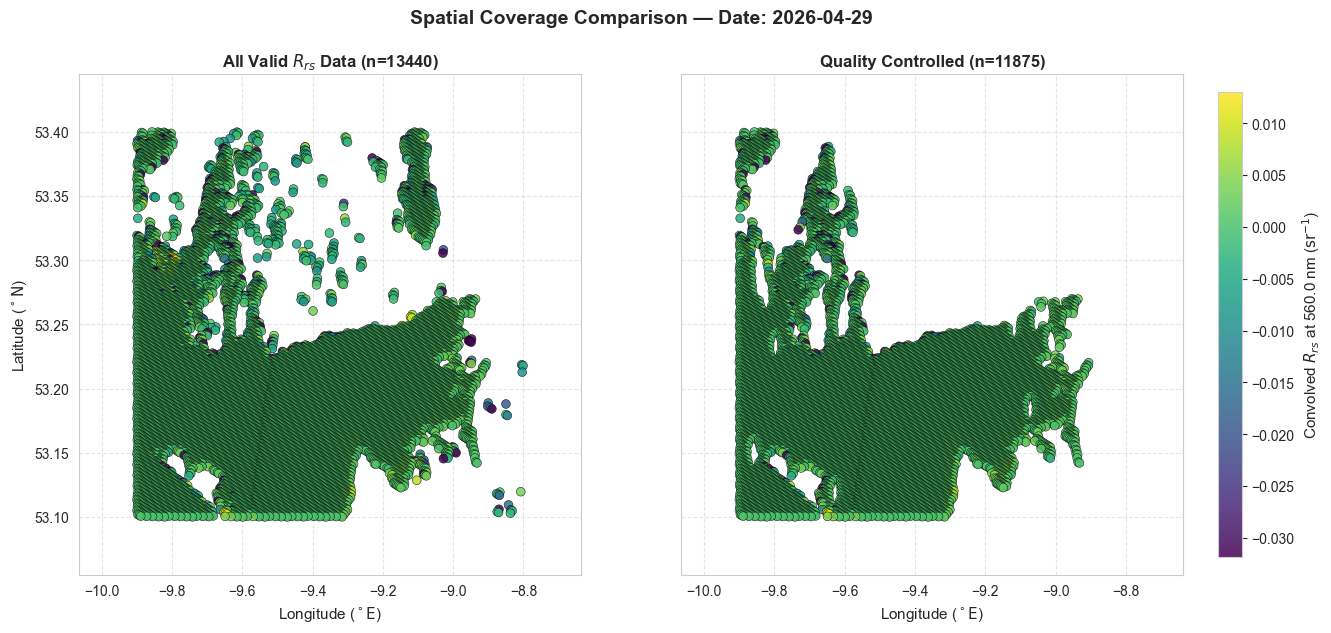

In [127]:
plot_spatial_flag_comparison(
    df_s3=df_s3b,
    target_date='2026-04-29',
    band_col='Rrs_560.0',  # or 'Rrs_560.0' depending on column naming
    lat_col='latitude',
    lon_col='longitude',
    date_col='datetime'
)

In [67]:
# Run this inline to see which exact flag columns are triggering True for that date:
df_day = df_s3a[pd.to_datetime(df_s3a['datetime']).dt.date == pd.to_datetime('2026-05-01').date()]
flag_cols = [c for c in df_day.columns if ('flag' in c.lower() or df_day[c].dtype == bool)]
print("Detected flag columns:", flag_cols)
print("Flag counts:\n", df_day[flag_cols].sum())

Detected flag columns: ['flag_INVALID', 'flag_LAND', 'flag_CLOUD', 'flag_CLOUD_AMBIGUOUS', 'flag_CLOUD_MARGIN', 'flag_SUNGLINT_RISK', 'flag_HIGH_GLINT', 'flag_COSMETIC', 'flag_SUSPECT', 'flag_HISOLZEN', 'flag_SATURATED']
Flag counts:
 flag_INVALID                0
flag_LAND                7873
flag_CLOUD               8378
flag_CLOUD_AMBIGUOUS       15
flag_CLOUD_MARGIN        1572
flag_SUNGLINT_RISK       3044
flag_HIGH_GLINT             0
flag_COSMETIC           18123
flag_SUSPECT            10762
flag_HISOLZEN             123
flag_SATURATED            868
dtype: int64


In [68]:
# 1. Check data types of flags
print(df_day[flag_cols].dtypes)

# 2. Check if clean_mask has any True values
clean_mask = ~(df_day[flag_cols].astype(bool).any(axis=1))
print(f"Total rows in df_day: {len(df_day)}")
print(f"Clean rows in mask: {clean_mask.sum()}")

# 3. Check for NaNs in spatial or optical columns
print("NaNs in Latitude:", df_day['latitude'].isna().sum())
print("NaNs in Longitude:", df_day['longitude'].isna().sum())
print("NaNs in Band:", df_day['Rrs_560.0'].isna().sum())

flag_INVALID            bool
flag_LAND               bool
flag_CLOUD              bool
flag_CLOUD_AMBIGUOUS    bool
flag_CLOUD_MARGIN       bool
flag_SUNGLINT_RISK      bool
flag_HIGH_GLINT         bool
flag_COSMETIC           bool
flag_SUSPECT            bool
flag_HISOLZEN           bool
flag_SATURATED          bool
dtype: object
Total rows in df_day: 31031
Clean rows in mask: 0
NaNs in Latitude: 0
NaNs in Longitude: 0
NaNs in Band: 22646


In [73]:
target_dt = pd.to_datetime('2026-05-01').date()
df_day = df_s3a[pd.to_datetime(df_s3a['datetime']).dt.date == target_dt].copy()

# 1. Non-NaN optical counts
valid_rrs = df_day['Rrs_560.0'].notna()
print(f"Total rows on date: {len(df_day)}")
print(f"Rows with non-NaN Rrs_560.0: {valid_rrs.sum()}")

# 2. Fatal flag mask on non-NaN data
fatal_flags = ['flag_INVALID', 'flag_LAND', 'flag_CLOUD', 'flag_CLOUD_AMBIGUOUS', 'flag_CLOUD_MARGIN', 'flag_HIGH_GLINT', 'flag_SATURATED']
active_fatal = [c for c in fatal_flags if c in df_day.columns]

df_valid_rrs = df_day[valid_rrs]
clean_mask = ~(df_valid_rrs[active_fatal].fillna(False).astype(bool).any(axis=1))

print(f"Rows passing fatal flags: {clean_mask.sum()}")
print("\nFatal Flag counts ONLY on valid Rrs rows:")
print(df_valid_rrs[active_fatal].sum())

# 3. Coordinate bounds inspect
print("\nLatitude min/max:", df_valid_rrs['latitude'].min(), df_valid_rrs['latitude'].max())
print("Longitude min/max:", df_valid_rrs['longitude'].min(), df_valid_rrs['longitude'].max())

Total rows on date: 31031
Rows with non-NaN Rrs_560.0: 8385
Rows passing fatal flags: 0

Fatal Flag counts ONLY on valid Rrs rows:
flag_INVALID               0
flag_LAND               7873
flag_CLOUD              8378
flag_CLOUD_AMBIGUOUS      15
flag_CLOUD_MARGIN       1572
flag_HIGH_GLINT            0
flag_SATURATED           512
dtype: int64

Latitude min/max: 53.100007 53.399860999999994
Longitude min/max: -9.899987999999999 -8.800201


In [79]:
import pandas as pd

# Filter May 1st data with valid Rrs values
target_dt = pd.to_datetime('2026-05-01').date()
df_day = df_s3a[pd.to_datetime(df_s3a['datetime']).dt.date == target_dt].copy()
df_valid = df_day[df_day['Rrs_560.0'].notna()].copy()

print(f"Total valid Rrs_560.0 points on May 1st: {len(df_valid)}")
print("-" * 55)

# List of all detected flags
all_flags = [c for c in df_valid.columns if 'flag' in c.lower() or df_valid[c].dtype == bool]

# Evaluate impact of each flag individually
print(f"{'Flag Name':<25} | {'Flagged (True)':<15} | {'Clean (False)':<15}")
print("-" * 55)

for flag in all_flags:
    flagged_cnt = df_valid[flag].fillna(False).astype(bool).sum()
    clean_cnt = len(df_valid) - flagged_cnt
    print(f"{flag:<25} | {flagged_cnt:<15} | {clean_cnt:<15}")

Total valid Rrs_560.0 points on May 1st: 8385
-------------------------------------------------------
Flag Name                 | Flagged (True)  | Clean (False)  
-------------------------------------------------------
flag_INVALID              | 0               | 8385           
flag_LAND                 | 7873            | 512            
flag_CLOUD                | 8378            | 7              
flag_CLOUD_AMBIGUOUS      | 15              | 8370           
flag_CLOUD_MARGIN         | 1572            | 6813           
flag_SUNGLINT_RISK        | 3044            | 5341           
flag_HIGH_GLINT           | 0               | 8385           
flag_COSMETIC             | 512             | 7873           
flag_SUSPECT              | 0               | 8385           
flag_HISOLZEN             | 66              | 8319           
flag_SATURATED            | 512             | 7873           


In [82]:
print(df_s3a.head(10))

  satellite            datetime   latitude  longitude  pixel_row  pixel_col  \
0       S3A 2026-04-26 11:36:24  53.399379  -8.811249       2788       4554   
1       S3A 2026-04-26 11:36:24  53.398443  -8.806941       2788       4555   
2       S3A 2026-04-26 11:36:24  53.397514  -8.802663       2788       4556   
3       S3A 2026-04-26 11:36:24  53.399681  -8.825647       2789       4550   
4       S3A 2026-04-26 11:36:24  53.399681  -8.825647       2789       4551   
5       S3A 2026-04-26 11:36:24  53.398754  -8.821377       2789       4552   
6       S3A 2026-04-26 11:36:24  53.397820  -8.817078       2789       4553   
7       S3A 2026-04-26 11:36:24  53.396886  -8.812774       2789       4554   
8       S3A 2026-04-26 11:36:24  53.395944  -8.808436       2789       4555   
9       S3A 2026-04-26 11:36:24  53.395016  -8.804166       2789       4556   

   Rrs_400.0  Rrs_412.5  Rrs_442.5  Rrs_490.0  ...  flag_LAND  flag_CLOUD  \
0        NaN        NaN        NaN        NaN  ...   

In [105]:
df_s3a

,satellite,datetime,latitude,longitude,pixel_row,pixel_col,Rrs_400.0,Rrs_412.5,Rrs_442.5,Rrs_490.0,...,flag_COSMETIC,flag_SUSPECT,flag_HISOLZEN,flag_SATURATED,flag_HIGHGLINT,flag_CLOUD_AMBIGUOUS,flag_CLOUD_MARGIN,flag_AC_FAIL,flag_OC4ME_FAIL,flag_OCNN_FAIL
0,S3A,2026-04-26 11:36:24,53.399379,-8.811249,2788,4554,NaN,NaN,NaN,NaN,...,False,False,False,False,False,False,False,False,False,False
1,S3A,2026-04-26 11:36:24,53.398443,-8.806941,2788,4555,NaN,NaN,NaN,NaN,...,False,False,False,False,False,False,False,False,False,False
2,S3A,2026-04-26 11:36:24,53.397514,-8.802663,2788,4556,NaN,NaN,NaN,NaN,...,False,False,False,False,False,False,False,False,False,False
3,S3A,2026-04-26 11:36:24,53.399681,-8.825647,2789,4550,NaN,NaN,NaN,NaN,...,False,False,False,False,False,False,False,False,False,False
4,S3A,2026-04-26 11:36:24,53.399681,-8.825647,2789,4551,NaN,NaN,NaN,NaN,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
373009,S3A,2026-05-10 10:32:51,53.100786,-9.878907,3789,511,0.000629,0.000528,0.000465,0.000489,...,False,False,False,False,False,False,False,False,False,False
373010,S3A,2026-05-10 10:32:51,53.100786,-9.878907,3789,512,0.000631,0.000530,0.000467,0.000491,...,False,False,False,False,False,False,False,False,False,False
373011,S3A,2026-05-10 10:32:51,53.100786,-9.878907,3789,513,0.000635,0.000535,0.000469,0.000491,...,False,False,False,False,False,False,False,False,False,False
373012,S3A,2026-05-10 10:32:51,53.100101,-9.869349,3789,514,0.000605,0.000528,0.000541,0.000458,...,False,False,False,False,False,False,False,False,False,False


In [106]:
# Step 1: Filter to target date
target_dt = pd.to_datetime('2026-05-01').date()
df_day = df_s3a[pd.to_datetime(df_s3a['datetime']).dt.date == target_dt].copy()

# Step 2: Drop rows where the target optical band is NaN BEFORE checking flags
df_valid_rrs = df_day[df_day['Rrs_560.0'].notna()].copy()

# Step 3: Apply ONLY essential fatal flags (Exclude COSMETIC & SUSPECT)
fatal_flags = [
    'flag_INVALID',
    'flag_LAND',
    'flag_CLOUD',
    'flag_CLOUD_AMBIGUOUS',
    'flag_CLOUD_MARGIN',
    'flag_HIGH_GLINT',
    'flag_SATURATED'
]

# Build mask strictly against available fatal flags
active_fatal = [c for c in fatal_flags if c in df_valid_rrs.columns]
clean_mask = ~(df_valid_rrs[active_fatal].fillna(False).astype(bool).any(axis=1))

df_clean = df_valid_rrs[clean_mask]

print(f"Total rows on date: {len(df_day)}")
print(f"Rows with non-NaN Rrs_560.0: {len(df_valid_rrs)}")
print(f"Clean water rows passing fatal flags: {len(df_clean)}")

Total rows on date: 31031
Rows with non-NaN Rrs_560.0: 8385
Clean water rows passing fatal flags: 4481


In [107]:
# 1. Filter May 1st non-NaN data
target_dt = pd.to_datetime('2026-05-01').date()
df_may1 = df_s3a[pd.to_datetime(df_s3a['datetime']).dt.date == target_dt].copy()
df_valid = df_may1[df_may1['Rrs_560.0'].notna()].copy()

print(f"Total rows May 1st: {len(df_may1)}")
print(f"Non-NaN Rrs_560.0 rows: {len(df_valid)}")

if not df_valid.empty:
    print("\n--- Boolean Flag Counts on Valid Rrs_560.0 Rows ---")
    flag_cols = [c for c in df_valid.columns if c.startswith('flag_')]
    for col in flag_cols:
        print(f"{col:<22}: {df_valid[col].sum()} True out of {len(df_valid)}")

    # Test filtering with JUST Cloud and Land
    water_mask = (~df_valid['flag_CLOUD']) & (~df_valid['flag_LAND'])
    print(f"\nPixels passing BOTH ~CLOUD and ~LAND: {water_mask.sum()}")

Total rows May 1st: 31031
Non-NaN Rrs_560.0 rows: 8385

--- Boolean Flag Counts on Valid Rrs_560.0 Rows ---
flag_INVALID          : 0 True out of 8385
flag_WATER            : 7873 True out of 8385
flag_LAND             : 512 True out of 8385
flag_CLOUD            : 0 True out of 8385
flag_SNOW_ICE         : 66 True out of 8385
flag_INLAND_WATER     : 512 True out of 8385
flag_TIDAL            : 467 True out of 8385
flag_COSMETIC         : 2864 True out of 8385
flag_SUSPECT          : 0 True out of 8385
flag_HISOLZEN         : 25 True out of 8385
flag_SATURATED        : 0 True out of 8385
flag_HIGHGLINT        : 0 True out of 8385
flag_CLOUD_AMBIGUOUS  : 758 True out of 8385
flag_CLOUD_MARGIN     : 3038 True out of 8385
flag_AC_FAIL          : 0 True out of 8385
flag_OC4ME_FAIL       : 772 True out of 8385
flag_OCNN_FAIL        : 1949 True out of 8385

Pixels passing BOTH ~CLOUD and ~LAND: 7873


Plotting 7873 clean pixels...


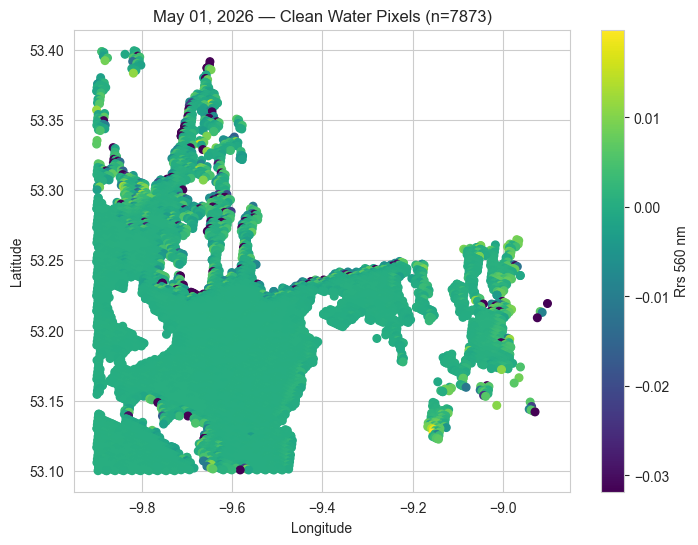

In [108]:
import matplotlib.pyplot as plt

target_dt = pd.to_datetime('2026-05-01').date()
df_may1 = df_s3a[pd.to_datetime(df_s3a['datetime']).dt.date == target_dt].copy()

# Filter: Non-NaN Rrs AND not Cloud AND not Land
clean_pts = df_may1[
    df_may1['Rrs_560.0'].notna() &
    (~df_may1['flag_CLOUD']) &
    (~df_may1['flag_LAND'])
]

print(f"Plotting {len(clean_pts)} clean pixels...")

plt.figure(figsize=(8, 6))
plt.scatter(
    clean_pts['longitude'],
    clean_pts['latitude'],
    c=clean_pts['Rrs_560.0'],
    cmap='viridis',
    s=30
)
plt.colorbar(label='Rrs 560 nm')
plt.title(f'May 01, 2026 — Clean Water Pixels (n={len(clean_pts)})')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True)
plt.show()

Plotting 0 clean pixels...


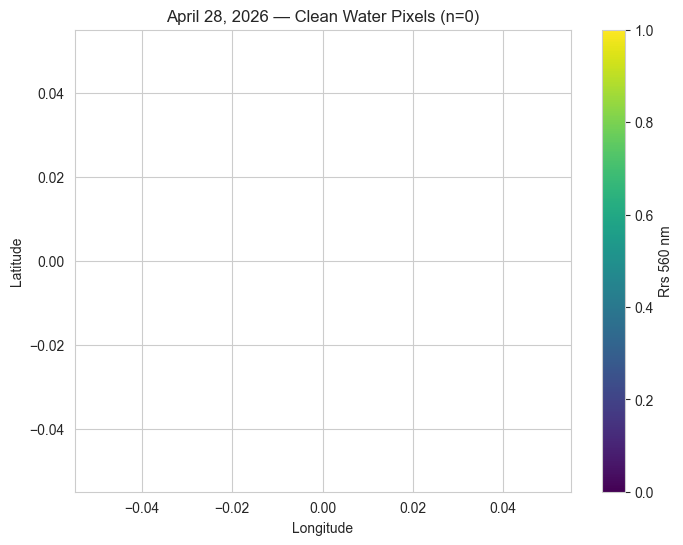

In [115]:

target_dt = pd.to_datetime('2026-04-28').date()
df_april28 = df_s3b[pd.to_datetime(df_s3b['datetime']).dt.date == target_dt].copy()

# Filter: Non-NaN Rrs AND not Cloud AND not Land
clean_pts = df_april28[
    df_april28['Rrs_560.0'].notna() &
    (~df_april28['flag_CLOUD']) &
    (df_april28['flag_WATER']==True)
]

print(f"Plotting {len(clean_pts)} clean pixels...")

plt.figure(figsize=(8, 6))
plt.scatter(
    clean_pts['longitude'],
    clean_pts['latitude'],
    c=clean_pts['Rrs_560.0'],
    cmap='viridis',
    s=30
)
plt.colorbar(label='Rrs 560 nm')
plt.title(f'April 28, 2026 — Clean Water Pixels (n={len(clean_pts)})')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True)
plt.show()

Plotting 12866 clean water pixels on April 28...


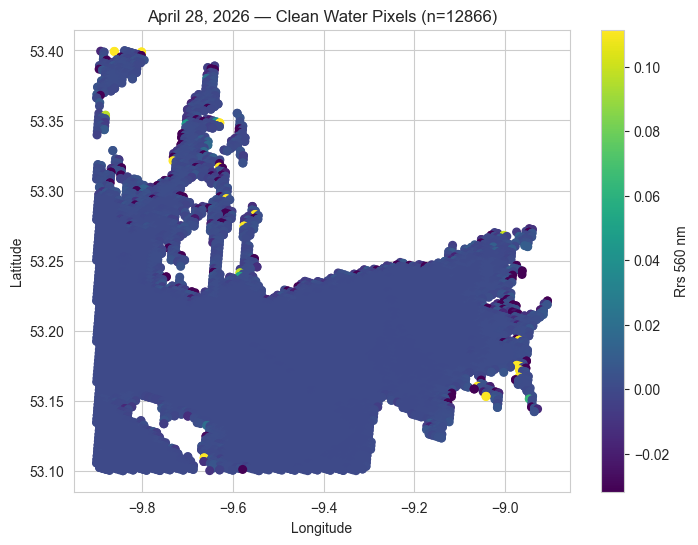

In [118]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Filter to April 28, 2026
target_dt = pd.to_datetime('2026-04-28').date()
df_april28 = df_s3a[pd.to_datetime(df_s3a['datetime']).dt.date == target_dt].copy()

# 2. Correct Marine Filtering: Water == True, Cloud == False, Invalid == False
clean_pts = df_april28[
    df_april28['Rrs_560.0'].notna() &
    (df_april28['flag_WATER'] == True) &
    (df_april28['flag_CLOUD'] == False) &
    (df_april28['flag_INVALID'] == False)
].copy()

print(f"Plotting {len(clean_pts)} clean water pixels on April 28...")

# 3. Render Scatter Plot
if not clean_pts.empty:
    plt.figure(figsize=(8, 6))
    plt.scatter(
        clean_pts['longitude'],
        clean_pts['latitude'],
        c=clean_pts['Rrs_560.0'],
        cmap='viridis',
        s=30
    )
    plt.colorbar(label='Rrs 560 nm')
    plt.title(f'April 28, 2026 — Clean Water Pixels (n={len(clean_pts)}) - S3B')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.grid(True)
    plt.show()
else:
    print("Check if df_s3b contains April 28 scenes or if the dataset was extracted from df_s3a instead.")

,satellite,datetime,latitude,longitude,pixel_row,pixel_col,Rrs_400.0,Rrs_412.5,Rrs_442.5,Rrs_490.0,...,flag_COSMETIC,flag_SUSPECT,flag_HISOLZEN,flag_SATURATED,flag_HIGHGLINT,flag_CLOUD_AMBIGUOUS,flag_CLOUD_MARGIN,flag_AC_FAIL,flag_OC4ME_FAIL,flag_OCNN_FAIL
62659,S3B,2026-04-28 11:46:23,53.399369,-9.810675,2677,4864,NaN,NaN,NaN,NaN,...,True,False,False,False,False,False,False,False,False,False
62660,S3B,2026-04-28 11:46:23,53.399502,-9.823637,2678,4861,NaN,NaN,NaN,NaN,...,True,False,False,False,False,False,False,False,False,False
62661,S3B,2026-04-28 11:46:23,53.398631,-9.819848,2678,4862,NaN,NaN,NaN,NaN,...,True,False,False,False,False,False,False,False,False,False
62662,S3B,2026-04-28 11:46:23,53.397760,-9.816060,2678,4863,NaN,NaN,NaN,NaN,...,True,False,False,False,False,False,False,False,False,False
62663,S3B,2026-04-28 11:46:23,53.396889,-9.812271,2678,4864,NaN,NaN,NaN,NaN,...,True,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63265,S3B,2026-04-28 11:46:23,53.268817,-9.898770,2730,4863,NaN,NaN,NaN,NaN,...,False,False,False,False,False,False,False,False,False,False
63266,S3B,2026-04-28 11:46:23,53.267948,-9.894991,2730,4864,NaN,NaN,NaN,NaN,...,False,False,False,False,False,False,False,False,False,False
63267,S3B,2026-04-28 11:46:23,53.265468,-9.896578,2731,4864,NaN,NaN,NaN,NaN,...,False,False,False,False,False,False,False,False,False,False
63268,S3B,2026-04-28 11:46:23,53.262988,-9.898164,2732,4864,NaN,NaN,NaN,NaN,...,False,False,False,False,False,False,False,False,False,False


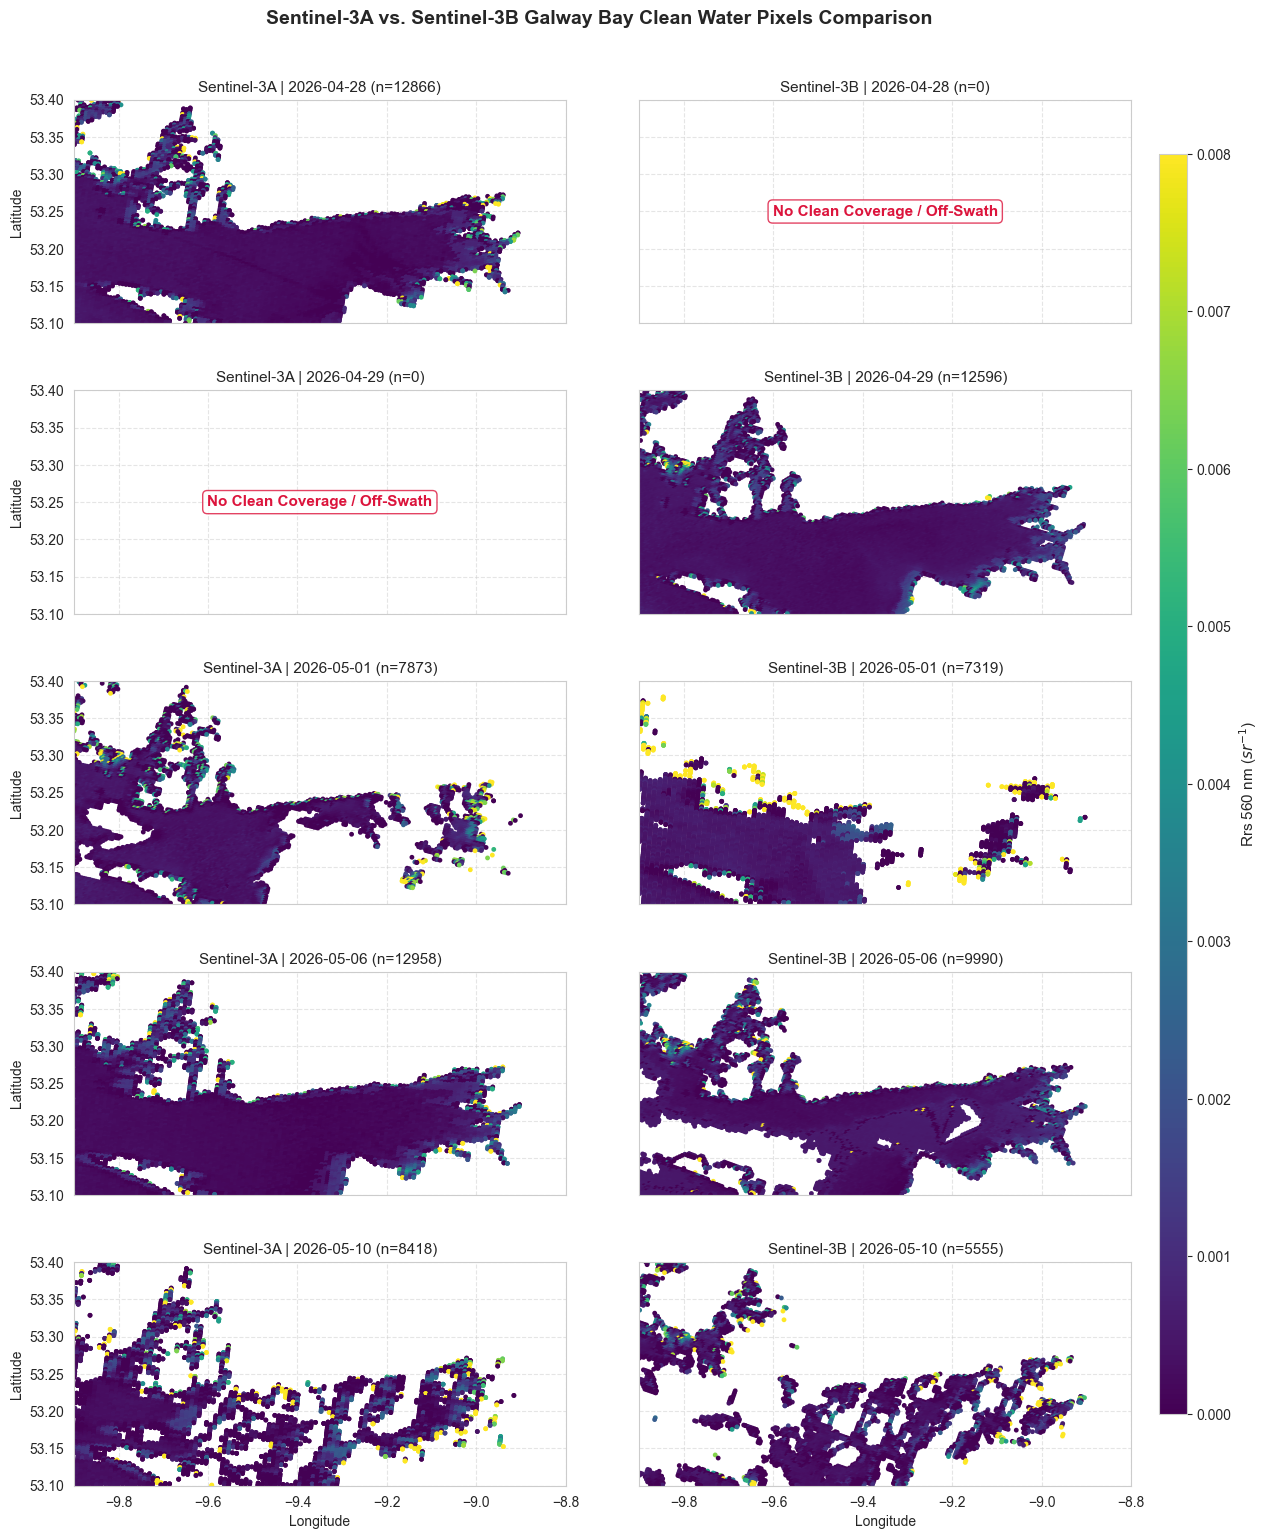

In [125]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Define dates and platforms
dates = ["2026-04-28", "2026-04-29", "2026-05-01", "2026-05-06", "2026-05-10"]
platforms = [("Sentinel-3A", df_s3a), ("Sentinel-3B", df_s3b)]

# Galway Bay Bounding Box limits for consistent plot axes
lon_min, lat_min, lon_max, lat_max = -9.9, 53.1, -8.8, 53.4

# Create 5-row, 2-column figure
fig, axes = plt.subplots(
    nrows=5, ncols=2, figsize=(14, 18), sharex=True, sharey=True
)

# Store global min/max for colorbar scaling across all panels
vmin, vmax = 0.0, 0.008

for row_idx, date_str in enumerate(dates):
    target_dt = pd.to_datetime(date_str).date()

    for col_idx, (p_name, df_plat) in enumerate(platforms):
        ax = axes[row_idx, col_idx]

        # Filter by Date
        df_day = df_plat[
            pd.to_datetime(df_plat["datetime"]).dt.date == target_dt
        ].copy()

        # Apply Corrected Marine Filtering
        if not df_day.empty and "flag_WATER" in df_day.columns:
            clean_pts = df_day[
                df_day["Rrs_560.0"].notna()
                & (df_day["flag_WATER"] == True)
                & (df_day["flag_CLOUD"] == False)
                & (df_day["flag_INVALID"] == False)
            ]
        else:
            clean_pts = pd.DataFrame()

        # Plot clean pixels if available
        if not clean_pts.empty:
            sc = ax.scatter(
                clean_pts["longitude"],
                clean_pts["latitude"],
                c=clean_pts["Rrs_560.0"],
                cmap="viridis",
                s=12,
                vmin=vmin,
                vmax=vmax,
                edgecolors="none",
            )
            ax.set_title(
                f"{p_name} | {date_str} (n={len(clean_pts)})",
                fontsize=11,
                fontweight="normal",
            )
        else:
            # Display explicitly when no clean water pixels exist
            ax.text(
                0.5,
                0.5,
                "No Clean Coverage / Off-Swath",
                ha="center",
                va="center",
                transform=ax.transAxes,
                fontsize=11,
                color="crimson",
                fontweight="bold",
                bbox=dict(
                    boxstyle="round,pad=0.3",
                    facecolor="white",
                    edgecolor="crimson",
                    alpha=0.8,
                ),
            )
            ax.set_title(
                f"{p_name} | {date_str} (n=0)", fontsize=11, fontweight="normal"
            )

        # Formatting
        ax.set_xlim(lon_min, lon_max)
        ax.set_ylim(lat_min, lat_max)
        ax.grid(True, linestyle="--", alpha=0.5)

        if row_idx == 4:
            ax.set_xlabel("Longitude", fontsize=10)
        if col_idx == 0:
            ax.set_ylabel("Latitude", fontsize=10)

# Add shared colorbar on the right side
fig.subplots_adjust(right=0.88, hspace=0.3, wspace=0.15)
cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.7])
sm = plt.cm.ScalarMappable(
    cmap="viridis", norm=plt.Normalize(vmin=vmin, vmax=vmax)
)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label("Rrs 560 nm ($sr^{-1}$)", fontsize=11)

plt.suptitle(
    "Sentinel-3A vs. Sentinel-3B Galway Bay Clean Water Pixels Comparison",
    fontsize=14,
    fontweight="bold",
    y=0.93,
)

plt.show()
